In [1]:
#! pip install polars seaborn matplotlib openpyxl -q
#! pip install pyarrow -q
#! pip install nltk -q
#! pip install wordcloud -q
! python --version

Python 3.13.12


In [2]:
import re
import nltk

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS

from matplotlib.colors import to_hex  

#nltk.download('punkt')
#nltk.download('punkt_tab')
#nltk.download('wordnet')


## Load Data

In [3]:


df_overlay = pd.read_excel(
    io='revision_data.xlsx', 
    sheet_name='1_Sobreposição', 
    engine='openpyxl',
    usecols='A:B',
    skiprows=0,
    header=0
)

df_overlay = pl.DataFrame(df_overlay)
df_overlay.head()


title,source
str,str
"""<i>SeNSe</i>: embedding alignm…","""Google Scholar"""
"""A MultilingualBERT EmbeddingsA…",null
"""A Pretraining Approach for Sma…","""Google Scholar"""
"""A Survey on the Impact of Pre-…","""Springer International Journal…"
"""A common-specific feature cros…","""Springer International Journal…"


In [4]:

df_data = pd.read_excel(
    io='revision_data.xlsx', 
    sheet_name='3_Dados', 
    engine='openpyxl',
    usecols='A:T',
    skiprows=2,
    header=0
)

df_data = pl.DataFrame(df_data)
df_data.head()

"Código do artigo (ex: A01, A02).",Ano de publicação (filtro: $\geq$ 2023).,Nome completo do trabalho.,Google Scholar ou IJDSA.,URL,Nacionalidade Autores,Revista,Idioma Dataset,Domínio,Target,Embeddings,Estratégia,Tunning,Classe modelo,Tamanho Dataset,Métricas,Vantagens,Limitações,Contribuições,Ganho Relativo ao Baseline
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
1,2024,"""Adequate Prompting Improves Pe…","""Google Scholar""","""https://dl.acm.org/doi/abs/10.…","""Italy""","""Association for Computing Mach…","""English, Italian""","""Psychology""","""VAD""","""Contextual""","""Sentence""","""Fine-Tuning""","""Deep Learning & Neural Network…","""""10548"", ""10062""""","""Pearson Correlation""","""Does not require an exclusive …","""Transparency""","""Methodological Application, Fi…",0.012397
2,2023,"""Dating Greek papyri withtext r…","""Google Scholar""","""https://aclanthology.org/2023.…","""Greece, Sweeden, Switzerland, …","""Association for Computational …","""Greek""","""Palaeography""","""Century of document""","""Classical""","""Token, Sentence""","""Fine-Tuning""","""Linear & Statistical Models, T…","""""389""""","""MAE, MSE, R²""","""Human effort reduction, Novel …","""Data loss, Data Quality, Data …","""Dataset/Resource, Methodologic…",0.474256
3,2023,"""Designing a forecasting assist…","""Google Scholar""","""https://link.springer.com/arti…","""Iran""","""Springer Soft Computing""","""English""","""Finance""","""Bitcoin Closing Price of Next …","""Hybrid""","""Token, Document""","""Fine-Tuning""","""Deep Learning & Neural Network…","""""1200000""""","""R², MSE, RMSE, MedAE""","""Better metrics""","""Lack of benchmarks, Lack of tr…","""Multimodal Integration""",0.0
4,2024,"""Investigation of graph-based c…","""Springer International Journal…","""https://link.springer.com/arti…","""Bangladesh""","""Springer International Journal…","""English""","""Political Science""","""Fatality Count""","""Hybrid""","""Token""","""Fine-Tuning""","""Deep Learning & Neural Network…","""""13383""""","""R², MSE, RMSE""","""Captures relational dependenci…","""Computational Complexity, Sens…","""Methodological Application""",-0.065217
5,2023,"""Embeddingregression: Models fo…","""Google Scholar""","""https://www.cambridge.org/core…","""United States""","""American Political Science Rev…","""English""","""Political Science""","""Embedding Vector""","""Hybrid""","""Token""","""Frozen""","""Linear & Statistical Models""","""""400"", ""71""""","""Cluster Homogeneity, Cosine Si…","""Sample Efficiency, Speed, Tran…","""Assumption of Stability, Data …","""New Framework, Domain Insight""",0.0


In [5]:

df_wordcloud = pd.read_excel(
    io='revision_data.xlsx', 
    sheet_name='4_WordCloud', 
    engine='openpyxl',
    usecols='A:F',
    skiprows=2,
    header=0
)

df_wordcloud = pl.DataFrame(df_wordcloud)
df_wordcloud.head()


"Código do artigo (ex: A01, A02).",Ano de publicação (filtro: $\geq$ 2023).,Nome completo do trabalho.,Google Scholar ou IJDSA.,URL,Abstract
i64,i64,str,str,str,str
1,2024,"""Adequate Prompting Improves Pe…","""Google Scholar""","""https://dl.acm.org/doi/abs/10.…","""Regression models of natural l…"
2,2023,"""Dating Greek papyri withtext r…","""Google Scholar""","""https://aclanthology.org/2023.…","""Dating Greek papyri accurately…"
3,2023,"""Designing a forecasting assist…","""Google Scholar""","""https://link.springer.com/arti…","""Nowadays, the issue of fluctua…"
4,2024,"""Investigation of graph-based c…","""Springer International Journal…","""https://link.springer.com/arti…","""Determining fatality rates—a c…"
5,2023,"""Embeddingregression: Models fo…","""Google Scholar""","""https://www.cambridge.org/core…","""Social scientists commonly see…"


## WordCloud of abstracts

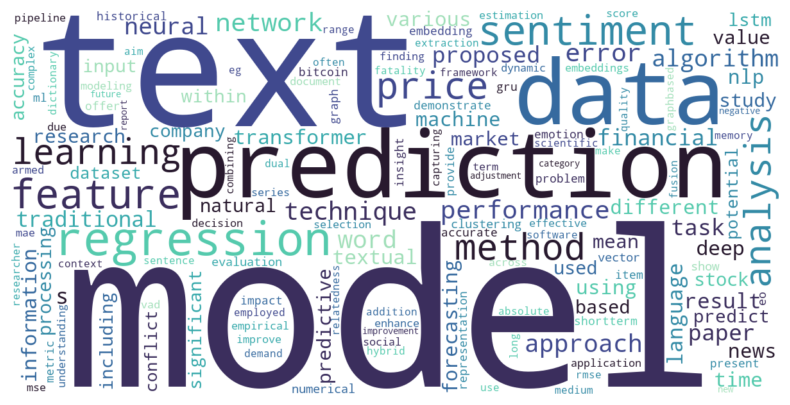

In [6]:

# Transform into single text
text = '\n'.join(df_wordcloud['Abstract'].to_list())

# Tokenize text
tokens = word_tokenize(text.lower())

# Keep only alphabetic characters
tokens = [re.sub(r'[^a-z]', '', word) for word in tokens]
tokens = [word for word in tokens if word != ""]

# Remove stop words
stop_words = set(STOPWORDS)
filtered_words = [word for word in tokens if word not in stop_words]

# Apply Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]

# Counter
freq = Counter(lemmatized_words)

# Frequency filtering
freq_filtered = {k: v for k, v in freq.items() if v > 1}

# Controlled scientific palette
palette = sns.color_palette("mako", 8)
palette_hex = [to_hex(c) for c in palette]

# Apply colors
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return np.random.choice(palette_hex)

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150,
    prefer_horizontal=0.9,
    relative_scaling=0.5,
    random_state=42,
    collocations=False
).generate_from_frequencies(freq_filtered)

# Configure image
plt.figure(figsize=(8, 4.5))
plt.imshow(wordcloud.recolor(color_func=color_func), interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

# Save and show
plt.savefig("wordcloud.pdf", dpi=600, bbox_inches="tight")
plt.show()


## 2 - Journals 

In [7]:

def plot_springer_style_bar_chart(
    data, 
    x_col, 
    y_col, 
    xlabel, 
    ylabel, 
    img_filename
):
    """
    Plot a horizontal bar chart with a style inspired by Springer publications.

    Parameters:
    - data: DataFrame containing the data to plot
    - x_col: Name of the column to use for the x-axis (values)
    - y_col: Name of the column to use for the y-axis (categories)
    - xlabel: Label for the x-axis
    - ylabel: Label for the y-axis
    - img_filename: Filename to save the image (e.g., "journal_plot.png")

    """

    # ---- Style configuration ----
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11
    })

    sns.set_style("white")

    fig, ax = plt.subplots(figsize=(7, 6))

    # Create a smooth color gradient
    #colors = sns.color_palette("Blues_r", len(journal_counts))
    colors = sns.color_palette("mako", len(data))

    bars = sns.barplot(
        data=data,
        y=y_col,
        x=x_col,
        palette=colors,
        ax=ax
    )

    # Light grid only on x-axis
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.grid(False)

    # Clean spines
    sns.despine(left=False, bottom=False)

    # Labels
    #ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Add value labels
    for i, v in enumerate(data[x_col]):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

    plt.tight_layout()

    # Save high resolution
    plt.savefig(img_filename, dpi=600, bbox_inches="tight")

    plt.show()
    

In [8]:

def plot_springer_style_bar_chart(
    data, 
    x_col, 
    y_col, 
    xlabel, 
    ylabel, 
    img_filename
):
    """
    Plot a horizontal bar chart with a style inspired by Springer publications.

    Parameters:
    - data: DataFrame containing the data to plot
    - x_col: Name of the column to use for the x-axis (values)
    - y_col: Name of the column to use for the y-axis (categories)
    - xlabel: Label for the x-axis
    - ylabel: Label for the y-axis
    - img_filename: Filename to save the image (e.g., "journal_plot.png")

    """

    # ---- Styling ----
    plt.style.use("default")

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "savefig.facecolor": "white"
    })

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.barplot(
        data=data,
        x=x_col,
        y=y_col,
        color="0.6",   # grayscale-friendly
        edgecolor="black",
        ax=ax
    )

    # ---- Add count labels ----
    for i, v in enumerate(data[x_col]):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=10)

    # ---- Axis labels ----
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # Save as vector + high-res raster
    plt.savefig(img_filename, dpi=600, bbox_inches="tight")

    plt.show()


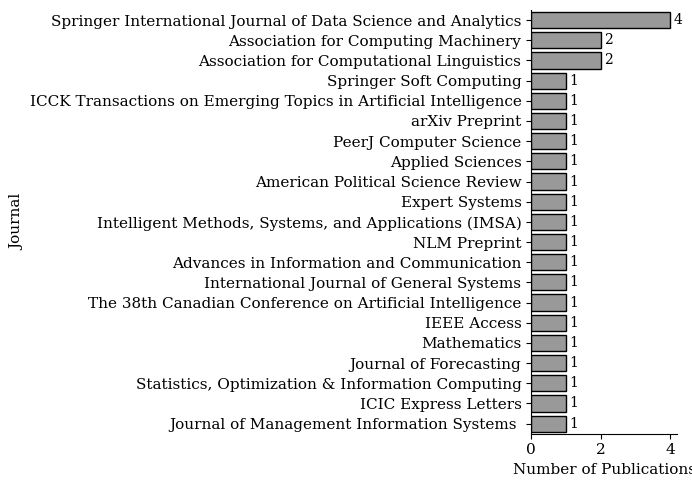

In [9]:

journal_counts = (
    df_data.select('Revista')
    .to_series()
    .value_counts()
    .sort('count', descending=True)
)

plot_springer_style_bar_chart(
    journal_counts, 
    x_col="count",
    y_col="Revista",
    ylabel="Journal",
    xlabel="Number of Publications",
    img_filename="journal_plot_springer_style.pdf"
)


# 3 - Author's country vs. Dataset Idiom

In [10]:

def plot_springer_style_count_heat_map(
    data: pd.DataFrame,
    xlabel: str,
    ylabel: str,
    cbar_label: str,
    img_filename: str,
    vmax: float = None,
    fmt: str = '.2g'
):
    
    plt.style.use('default')

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white"
    })

    plt.figure(figsize=(10, 7))
    cmap = sns.color_palette("light:#1f4e79", as_cmap=True)

    sns.heatmap(
        data,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        annot=True,
        fmt=fmt,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={'label': cbar_label}
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.savefig(img_filename, dpi=600, bbox_inches="tight")
    plt.show()


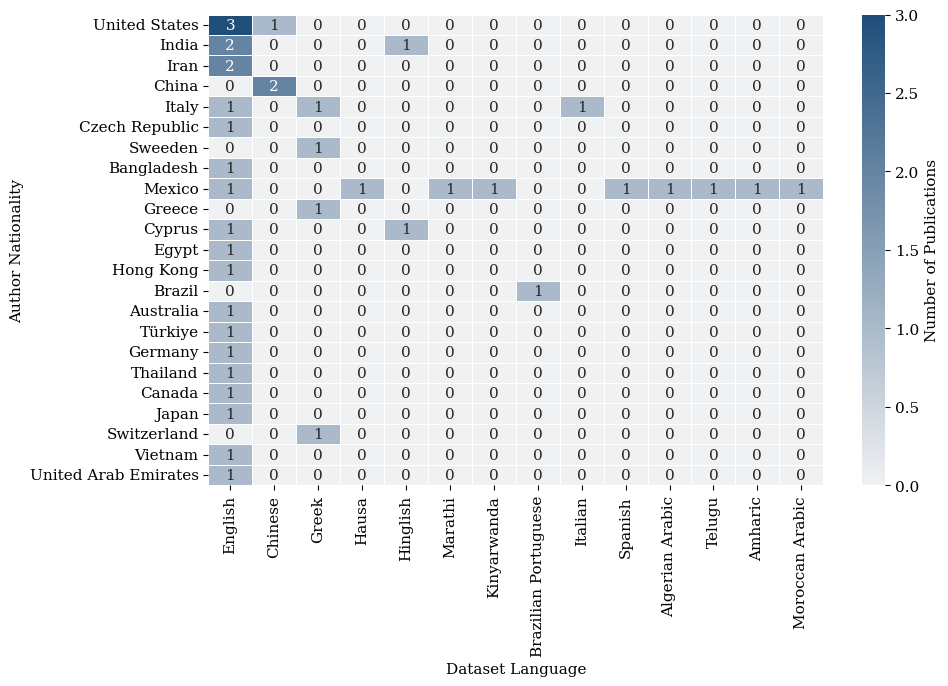

In [11]:
df_nationality_idiom = (
    df_data
    .filter(
        pl.col('Domínio').is_not_null()
    ).with_columns(
        pl.col('Nacionalidade Autores').str.split(',').alias('Nacionalidades'),
        pl.col('Idioma Dataset').str.split(',').alias('Idiomas')
    ).explode(
        'Nacionalidades'
    ).explode(
        'Idiomas'
    ).with_columns(
        pl.col('Nacionalidades')
            .str.strip_chars()
            .alias('Nacionalidades'),
        pl.col('Idiomas')
            .str.replace(r'and\s+', '', literal=False)
            .str.replace(
                r'\s*\(Inferred from dataset sources like Amazon/Yelp/Boston/UCI\)\.?',
                '',
                literal=False
            )
            .str.strip_chars()
            .alias('Idiomas')
    ).select(
        'Nacionalidades',
        'Idiomas'
    )
    .group_by(
        'Nacionalidades', 
        'Idiomas'
    ).len()
    .sort('len', descending=True)
    .pivot(
        index='Nacionalidades',
        on='Idiomas',
        values='len',
        aggregate_function='sum'
    )
    .to_pandas().set_index('Nacionalidades')
    .fillna(0)
)

plot_springer_style_count_heat_map(
   df_nationality_idiom,
   xlabel='Dataset Language',
   ylabel='Author Nationality',
   cbar_label='Number of Publications',
   img_filename='nationality_language_heatmap.pdf'
)



## 4 - Domain vs Target

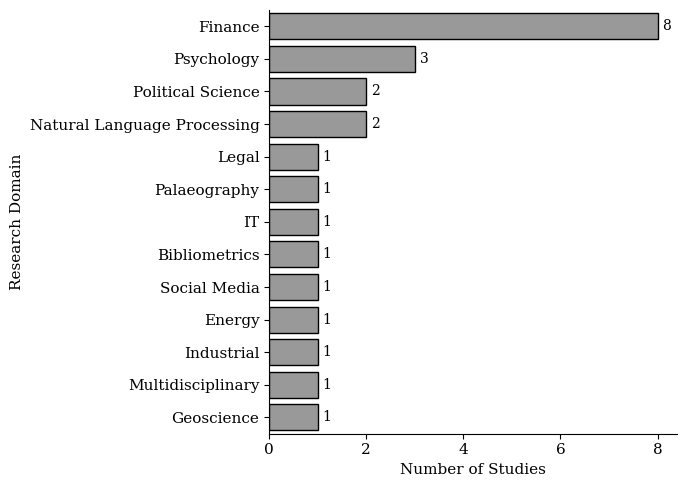

In [12]:


df_domains = (
    df_data
    .filter(
        pl.col('Domínio').is_not_null()
    ).with_columns(
        pl.col('Domínio').str.split(',').alias('Domínios')
    ).explode(
        'Domínios'
    ).with_columns(
        pl.col('Domínios')
            .str.strip_chars()
            .alias('Domínios')
    ).select(
        'Domínios'
    ).group_by(
        'Domínios'
    ).len()
    .sort('len', descending=True)
    .to_pandas()
)

plot_springer_style_bar_chart(
    df_domains,
    x_col='len',
    y_col='Domínios',
    xlabel='Number of Studies',
    ylabel='Research Domain',
    img_filename='research_domains_distribution.pdf'
)


In [13]:

STATISTICAL_TARGET_MAP = {
    "Temporal": [
        "Bitcoin Closing Price of Next Day",
        "Next day's closing price",
        "Soybean Futures Price",
        "Plastic Resin Price",
        "Renewable electricity generation/supply",
        "Century of document",
        "Heating/Cooling loads (energy)."
    ],

    "Continuous   ": [
        "Monetary value of compensation for immaterial damage",
        "Continuous geophysical/environmental variables",
        "Median home value (housing)",
        "Heating/Cooling loads (energy)",
        "Companie's Key Financial Indicators",
        "Company ROA",
        "Excess stock return",
        "Future earnings",
        "VAD",
        "Renewable electricity generation/supply",
        "Company ROA",
        "Relatedness Score",
        "Semantic Relatedness Score",
        "Fraud indicator",
        "Sentiment Intensity",
    ],

    "Count": [
        "Fatality Count",
        "Paper Citation Count",
        "Story Points of Issue Task",
    ],

    "Ordinal": [
        "Item Dificulty",
        "Sentiment scores (reviews)",
        
    ],

    "Multi-Dim.": [
        "Sadness",
        "Anger",
        "Nervousness",
        "Embedding Vector",
    ]
}

def get_class(target):
    for k, v in STATISTICAL_TARGET_MAP.items():
        if target in v:
            return k
    return None

In [14]:

def filtrar_apenas_artigos_com_dados(df: pl.DataFrame) -> pl.DataFrame:
    return df.filter(
        pl.col('Domínio').is_not_null()
    )

def renomear_codigo_artigo(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return df.rename(
        {'Código do artigo (ex: A01, A02).': alias}
    )

def gerar_coluna_dominio(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Domínio')
                .str.strip_chars()
                .str.split(',').alias('Domínios')
        ).explode(
            'Domínios'
        ).with_columns(
            pl.col('Domínios')
                .str.strip_chars()
                .alias(alias)
        )
    )

def gerar_coluna_classe_alvo(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Target')
                .str.split(',')
                .alias('Alvos')
        ).explode(
            'Alvos'
        ).with_columns(
            pl.col('Alvos')
                .str.strip_chars()
                .map_elements(lambda x: [k for k, v in STATISTICAL_TARGET_MAP.items() if x in v][0], return_dtype=pl.Utf8)
                .alias(alias)
        )
    )

def gerar_coluna_classe_modelo(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Classe modelo')
                .str.replace('(Sequential, Recurrent, & Attention)', '(Sequential & Recurrent & Attention)', literal=True)
                .str.strip_chars()
                .str.split(',').alias('Classe modelo'),
        ).explode(
            'Classe modelo'
        ).with_columns(
            pl.col('Classe modelo')
                .str.replace(' & ', ', ', literal=True)
                .str.strip_chars()
                .alias(alias)
        )
    )

def gerar_coluna_embedding(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Embeddings')
                .str.strip_chars()
                .str.split(',').alias('Embeddings')
        ).explode(
            'Embeddings'
        ).with_columns(
            pl.col('Embeddings')
                .str.strip_chars()
                .alias(alias)
        )
    )

def gerar_coluna_strategy(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df.with_columns(
            pl.col('Estratégia')
                .str.replace('(Lemmatized Word)', '', literal=True)
                .str.replace('Documents', 'Document', literal=True)
                .str.strip_chars()
                .str.split(',').alias('Estratégia')
        ).explode(
            'Estratégia'
        ).with_columns(
            pl.col('Estratégia')
                .str.strip_chars()
                .str.replace(' & ', ', ', literal=True)
                .alias(alias)
        )
    )

def gerar_df_heatmap_contagem(df: pl.DataFrame, col_id: str, col_x: str, col_y: str) -> pd.DataFrame:
    return (

        df
        # Filtrar apenas interesse
        .select(
            col_id,
            col_x,
            col_y
        )

        # Conta artigos unicos
        .group_by(
            col_x, col_y
        ).n_unique().rename(
            {col_id: 'len'}
        ).sort(
            'len', descending=True
        ).pivot(
            index=col_x,
            on=col_y,
            values='len',
            aggregate_function='sum'
        ).to_pandas().set_index(col_x).fillna(0)
    )

def gerar_coluna_log_dataset_size(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df.with_columns(
            pl.col('Tamanho Dataset')
                .str.replace(';', ',', literal=True)
                .str.split(',')
                .alias('Tamanho Dataset')
        ).explode(
            'Tamanho Dataset'
        ).with_columns(
            pl.col('Tamanho Dataset')
                .str.replace(r"[^\d]+", "", literal=False)
                .str.replace('"', '', literal=True)
                .cast(pl.Int64)
                .alias(alias)
        ).filter(
            pl.col(alias) > 0
        ).with_columns(
            pl.col(alias).log().alias(alias)
        )
    )

def gerar_coluna_metricas(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Métricas')
                .str.strip_chars()
                .str.split(',')
        ).explode(
            'Métricas'
        ).with_columns(
            pl.col('Métricas')
                .str.strip_chars()
                .alias(alias)
        )
    )


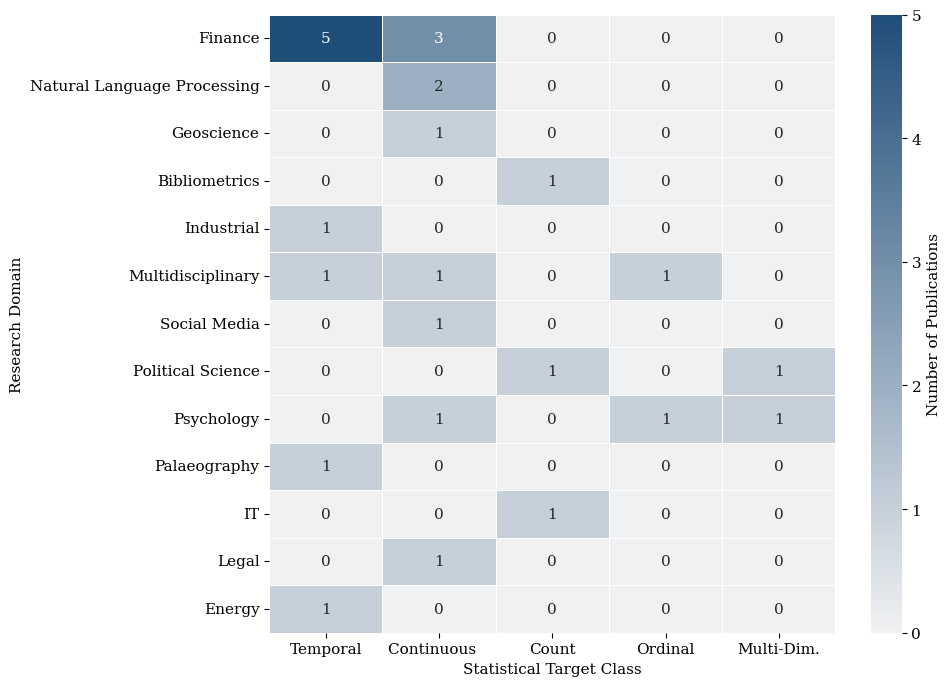

In [15]:
df_domain_target = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='Article Code')
    .pipe(gerar_coluna_dominio, alias='Domain')
    .pipe(gerar_coluna_classe_alvo, alias='Target Class')
    .pipe(gerar_df_heatmap_contagem, col_id='Article Code', col_x='Domain', col_y='Target Class')
)

plot_springer_style_count_heat_map(
    df_domain_target,
    xlabel='Statistical Target Class',
    ylabel='Research Domain',
    cbar_label='Number of Publications',
    img_filename='domain_target_heatmap.pdf'
)


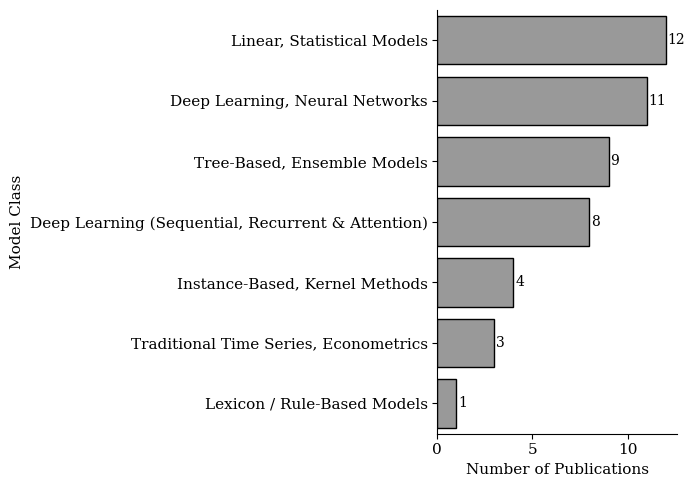

In [46]:

df_model_classes = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='Classe Modelo')
    .select('codigo_artigo', 'Classe Modelo').group_by('Classe Modelo').n_unique().rename({'codigo_artigo': 'len'}).sort('len', descending=True)
)

plot_springer_style_bar_chart(
    df_model_classes,
    x_col='len',
    y_col='Classe Modelo',
    xlabel='Number of Publications',
    ylabel='Model Class',
    img_filename='model_class_distribution.pdf'
)


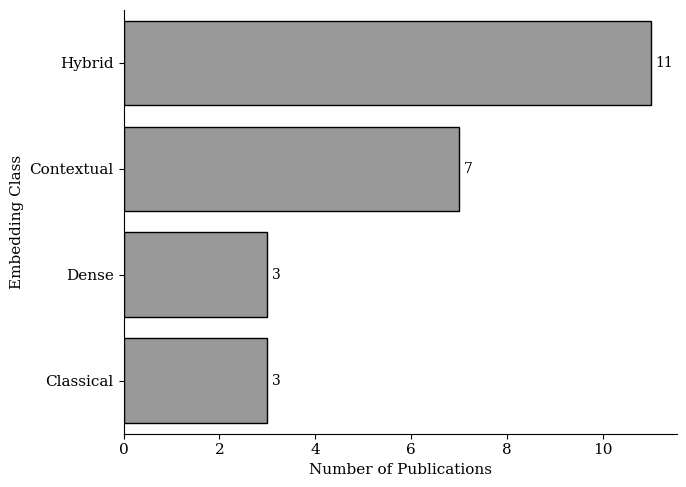

In [47]:

df_embedding_classes = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_embedding, alias='Classe Embedding')
    .select('codigo_artigo', 'Classe Embedding').group_by('Classe Embedding').n_unique().rename({'codigo_artigo': 'len'}).sort('len', descending=True)
)

plot_springer_style_bar_chart(
    df_embedding_classes,
    x_col='len',
    y_col='Classe Embedding',
    xlabel='Number of Publications',
    ylabel='Embedding Class',
    img_filename='embedding_class_distribution.pdf'
)


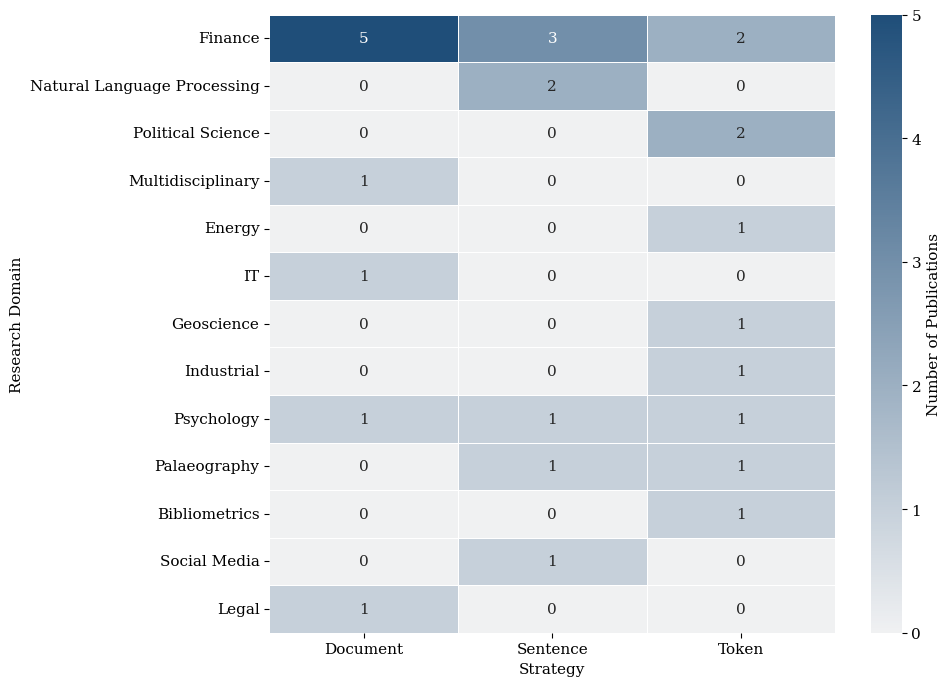

In [51]:

df_strategy_domain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_strategy, alias='Strategy')
    .pipe(gerar_coluna_dominio, alias='Domain')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Domain', col_y='Strategy')
)

plot_springer_style_count_heat_map(
   df_strategy_domain,
   xlabel='Strategy',
   ylabel='Research Domain',
   cbar_label='Number of Publications',
   img_filename='strategy_domain_heatmap.pdf'
)


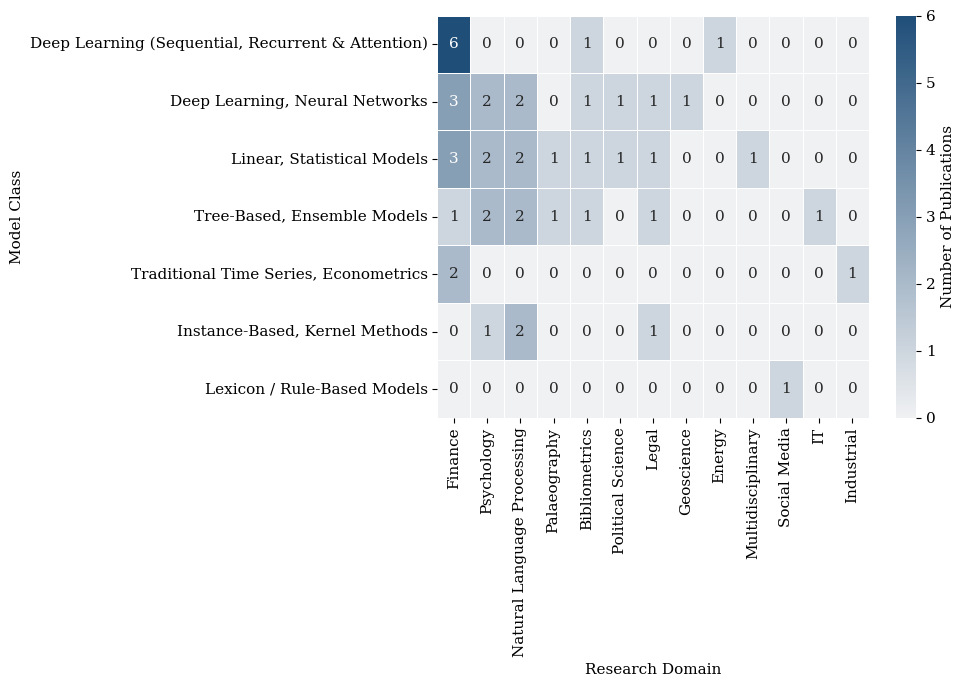

In [54]:
df_model_domain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='Model')
    .pipe(gerar_coluna_dominio, alias='Domain')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Model', col_y='Domain')
)

plot_springer_style_count_heat_map(
   df_model_domain,
   xlabel='Research Domain',
   ylabel='Model Class',
   cbar_label='Number of Publications',
   img_filename='model_domain_heatmap.pdf'
)

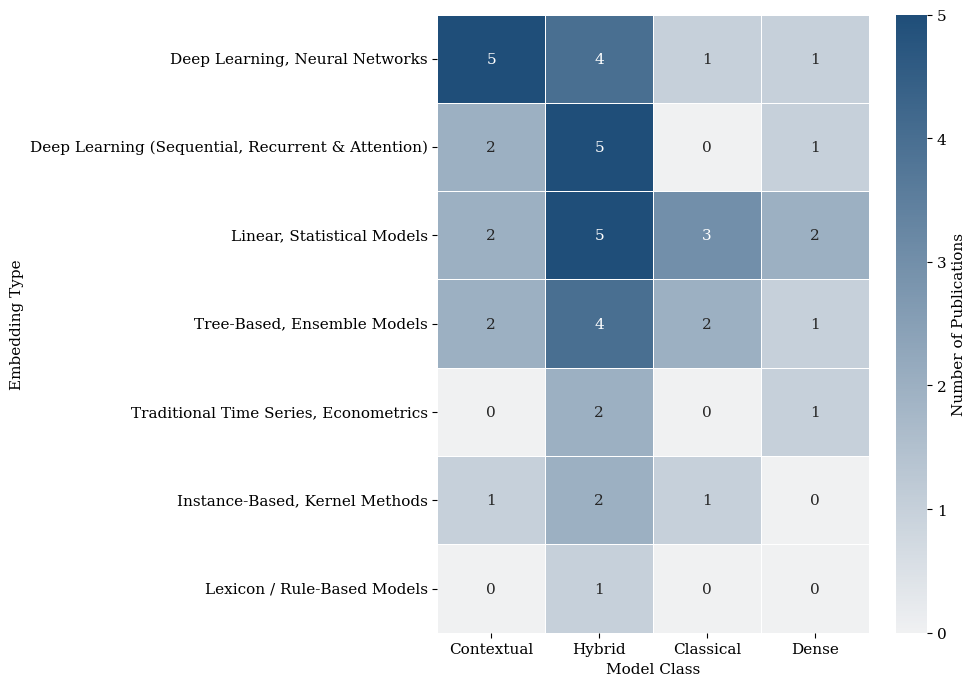

In [55]:
df_target_model = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_embedding, alias='Embedding Type')
    .pipe(gerar_coluna_classe_modelo, alias='Model Class')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Model Class', col_y='Embedding Type')
)

plot_springer_style_count_heat_map(
    df_target_model,
    xlabel='Model Class',
    ylabel='Embedding Type',
    cbar_label='Number of Publications',
    img_filename='model_embedding_heatmap.pdf'
)


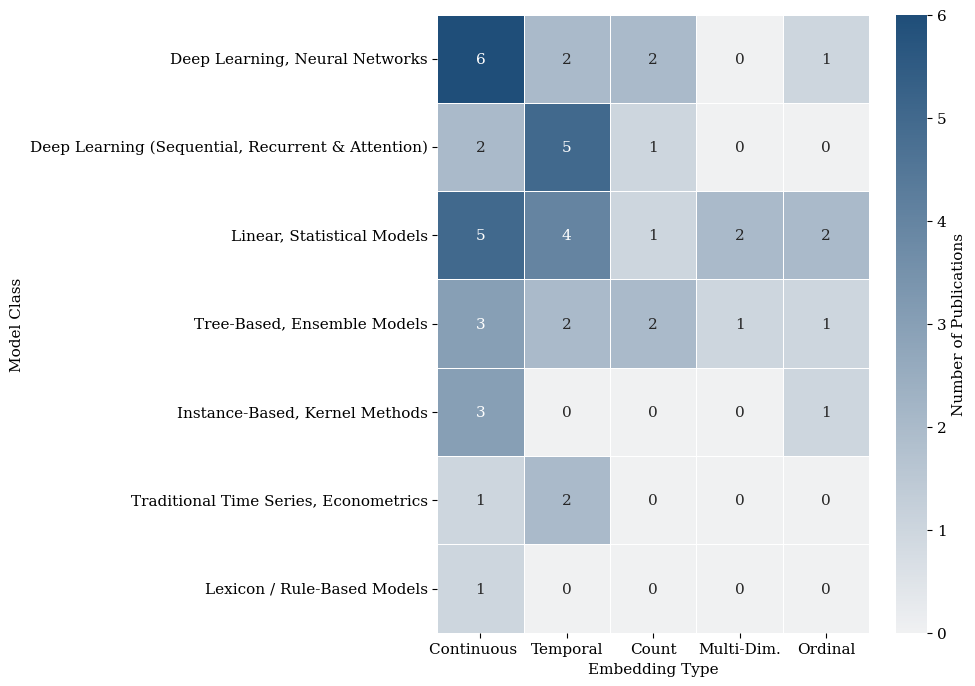

In [56]:
df_target_model = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_alvo, alias='Classe Alvo')
    .pipe(gerar_coluna_classe_modelo, alias='Classe modelo')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Classe modelo', col_y='Classe Alvo')
)

plot_springer_style_count_heat_map(
    df_target_model,
    xlabel='Embedding Type',
    ylabel='Model Class',
    cbar_label='Number of Publications',
    img_filename='model_target_heatmap.pdf'
)


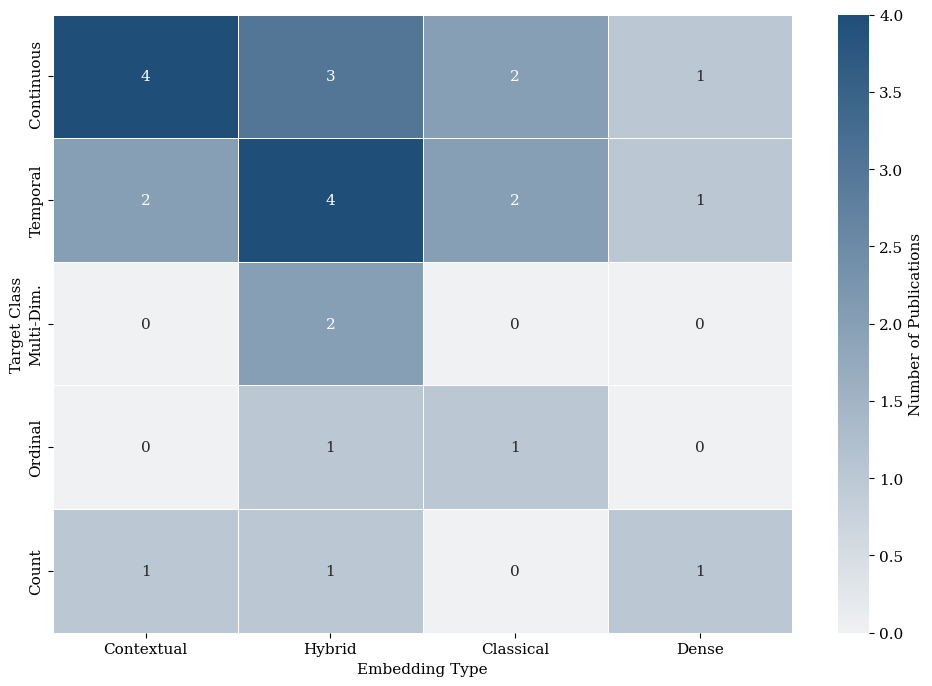

In [17]:


df_extraction_model = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_alvo, alias='Classe Alvo')
    .pipe(gerar_coluna_embedding, alias='Embeddings')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Classe Alvo', col_y='Embeddings')
)

plot_springer_style_count_heat_map(
    df_extraction_model,
    xlabel='Embedding Type',
    ylabel='Target Class',
    cbar_label='Number of Publications',
    img_filename='target_embedding_heatmap.pdf'
)


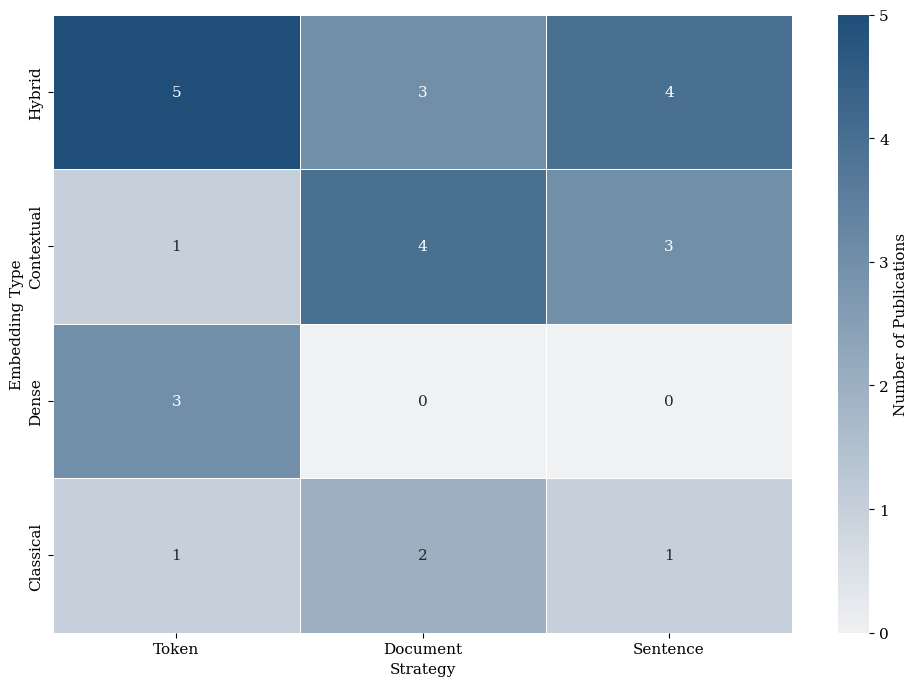

In [18]:

df_extraction_strategy = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='Classe modelo')
    .pipe(gerar_coluna_embedding, alias='Embeddings')
    .pipe(gerar_coluna_strategy, alias='Estratégia')
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Embeddings', col_y='Estratégia')
)

plot_springer_style_count_heat_map(
    df_extraction_strategy,
    xlabel='Strategy',
    ylabel='Embedding Type',
    cbar_label='Number of Publications',
    img_filename='strategy_embedding_heatmap.pdf'
)



In [19]:

def plot_springer_style_boxplot(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    order: list,
    xlabel: str,
    ylabel: str,
    img_filename: str
):

    plt.figure(figsize=(6, 4), dpi=300)

    sns.set_theme(style="white")

    ax = sns.boxplot(
        data=data,
        x=x_col,
        y=y_col,
        order=order,
        color='gray',
        linewidth=1,
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.tick_params(axis='both', labelsize=9)

    # Remove top/right spines (mais limpo)
    sns.despine()

    plt.tight_layout()
    plt.savefig(img_filename, dpi=600)
    plt.show()

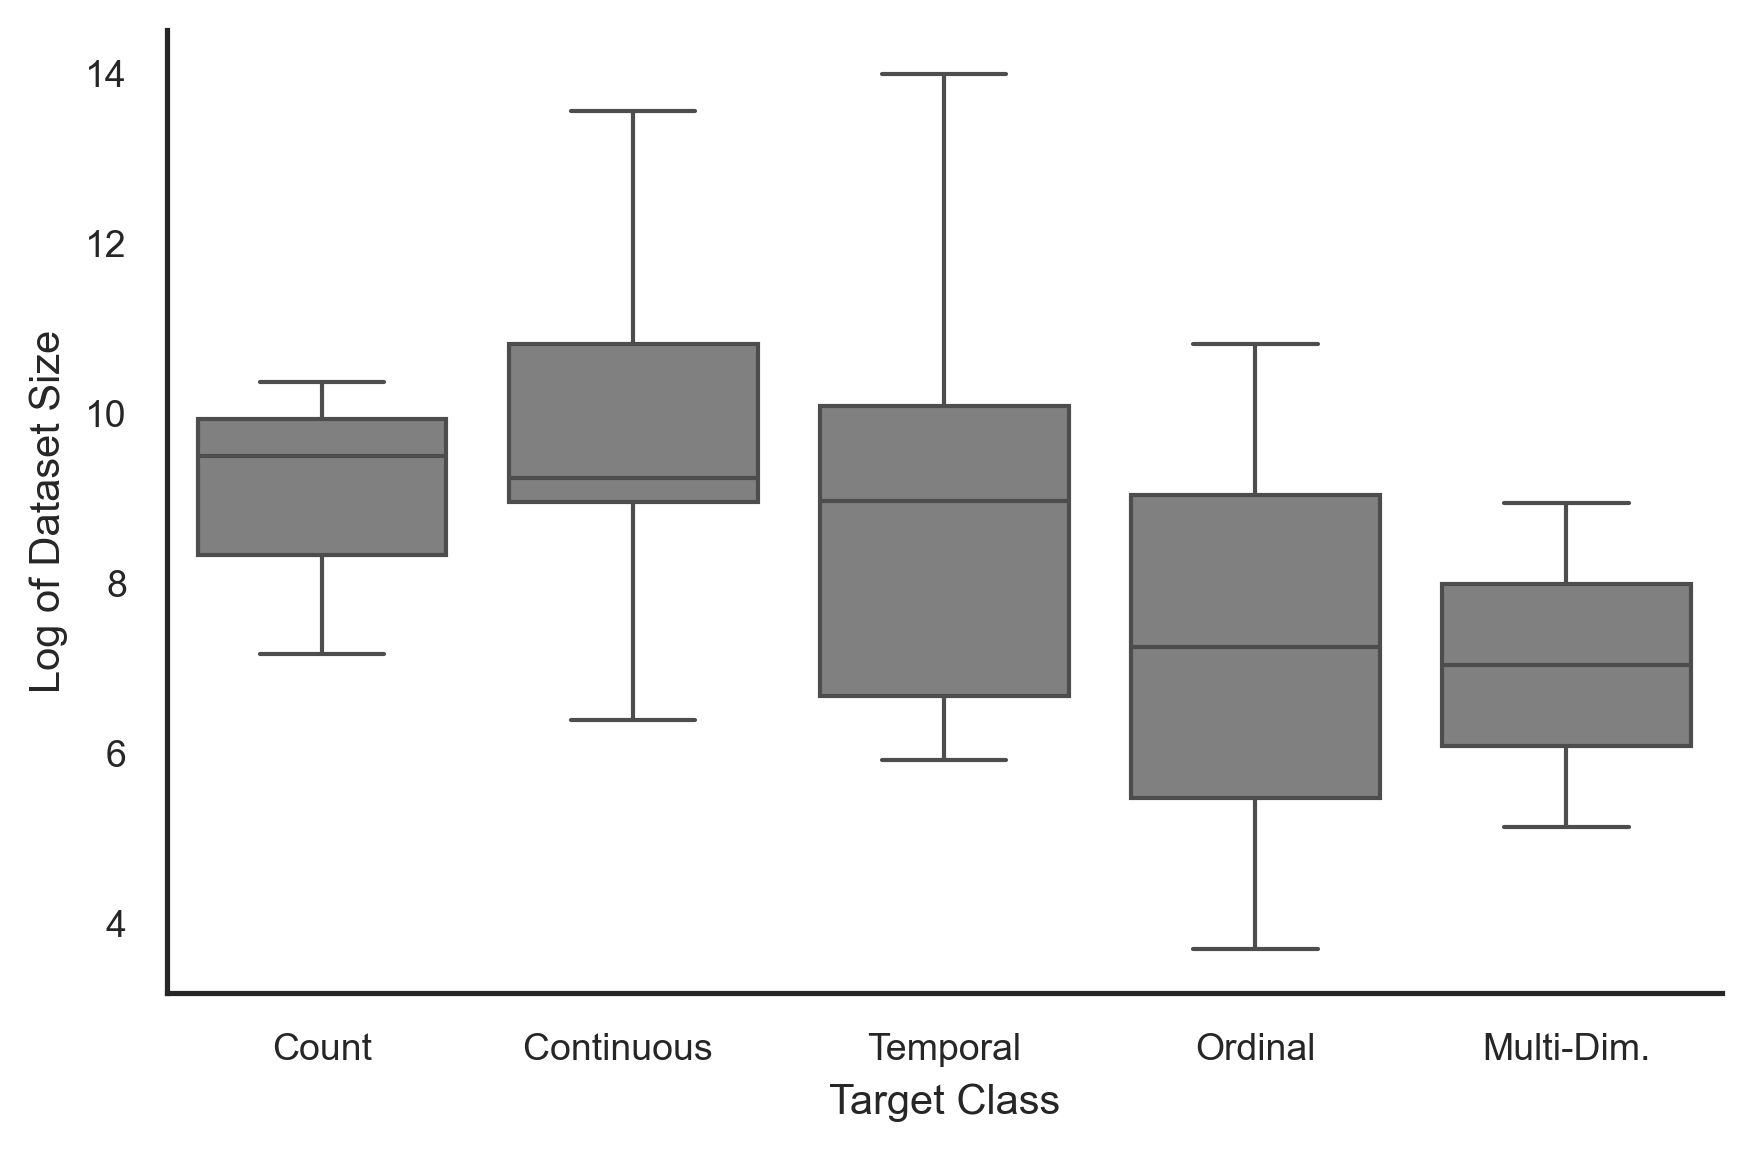

In [20]:
df_target_size = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_alvo, alias='classe_alvo')
    .pipe(gerar_coluna_log_dataset_size, alias='Log Dataset Size')
    .select('Log Dataset Size', 'classe_alvo', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_alvo').mean()
    .to_pandas()
)

df_target_size_order = (
    df_target_size.groupby('classe_alvo')['Log Dataset Size']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_target_size,
    x_col='classe_alvo',
    y_col='Log Dataset Size',
    order=df_target_size_order,
    xlabel='Target Class',
    ylabel='Log of Dataset Size',
    img_filename='target_class_dataset_size_boxplot.pdf'
)



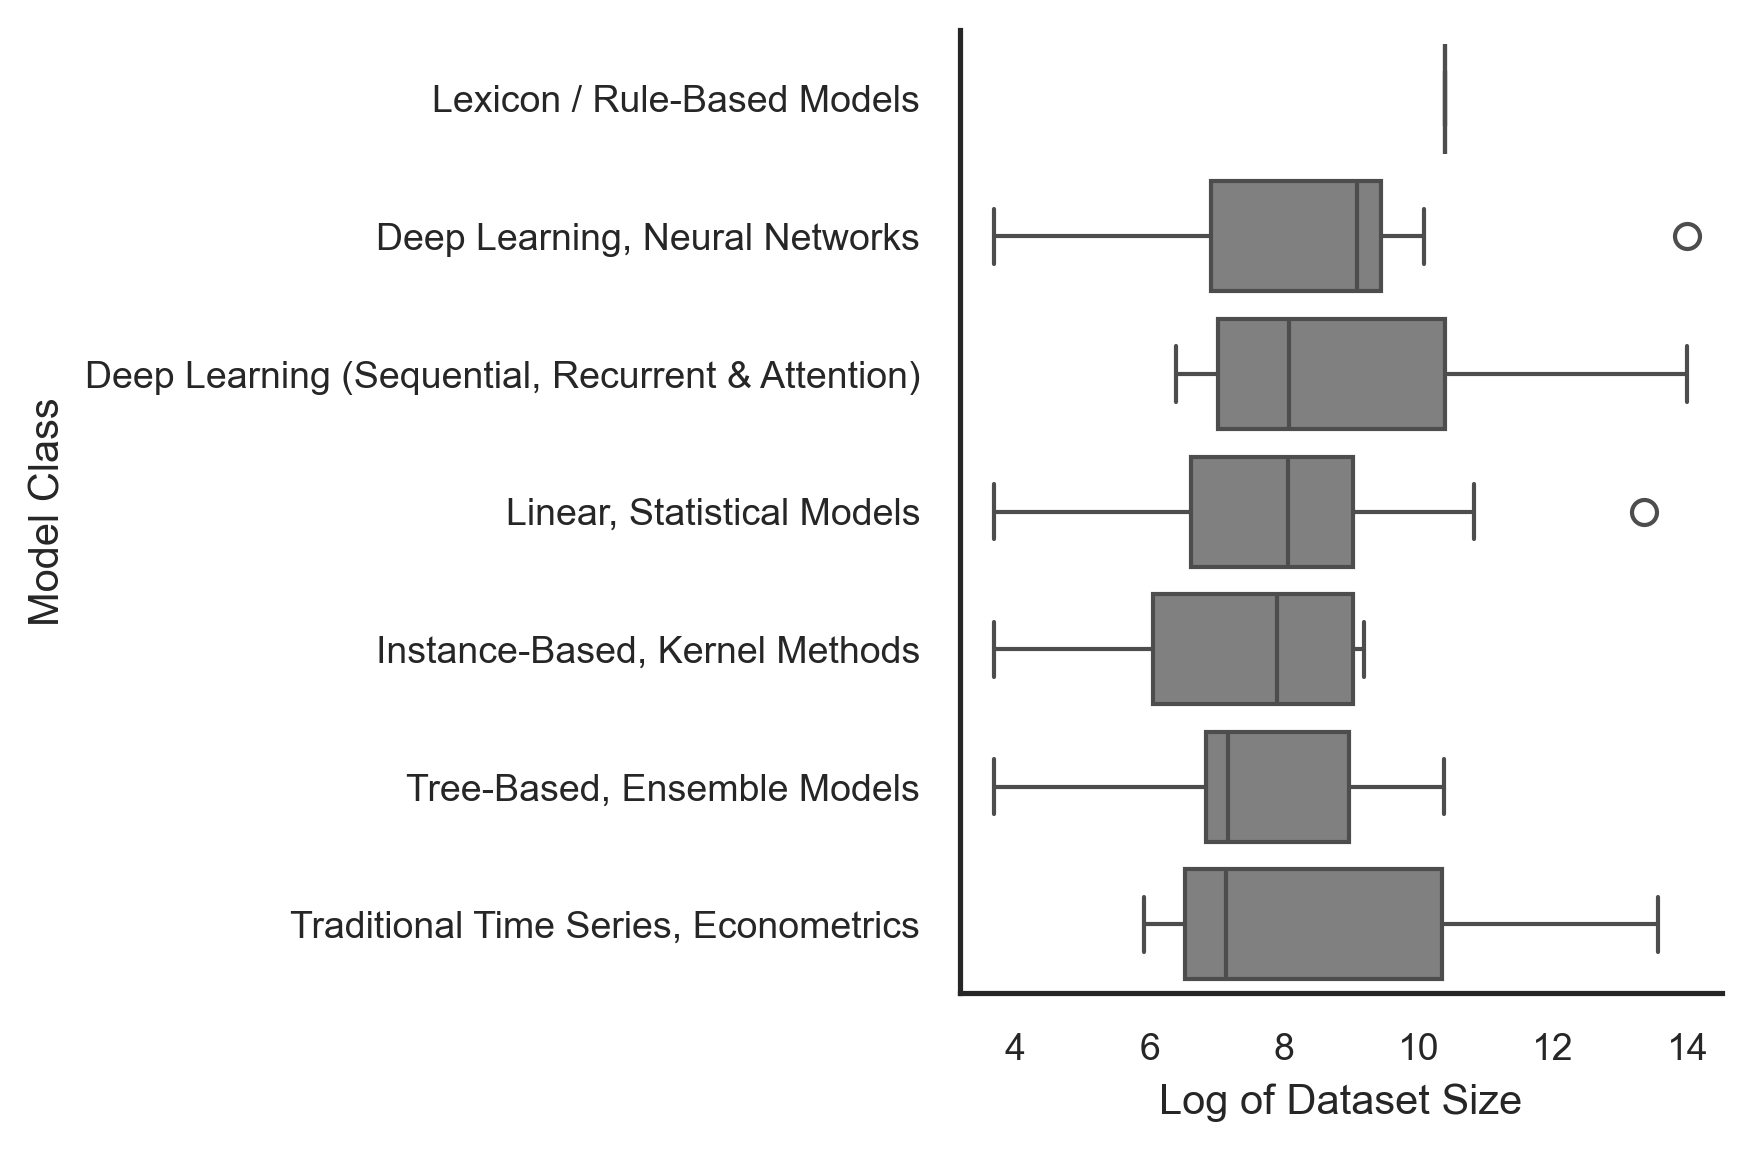

In [21]:

df_model_size = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='classe_modelo')
    .pipe(gerar_coluna_log_dataset_size, alias='Log Dataset Size')
    .select('Log Dataset Size', 'classe_modelo', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_modelo').mean().to_pandas()
)

df_model_size_order = (
    df_model_size.groupby('classe_modelo')['Log Dataset Size']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_model_size,
    x_col='Log Dataset Size',
    y_col='classe_modelo',
    order=df_model_size_order,
    xlabel='Log of Dataset Size',
    ylabel='Model Class',
    img_filename='model_class_dataset_size_boxplot.pdf'
)


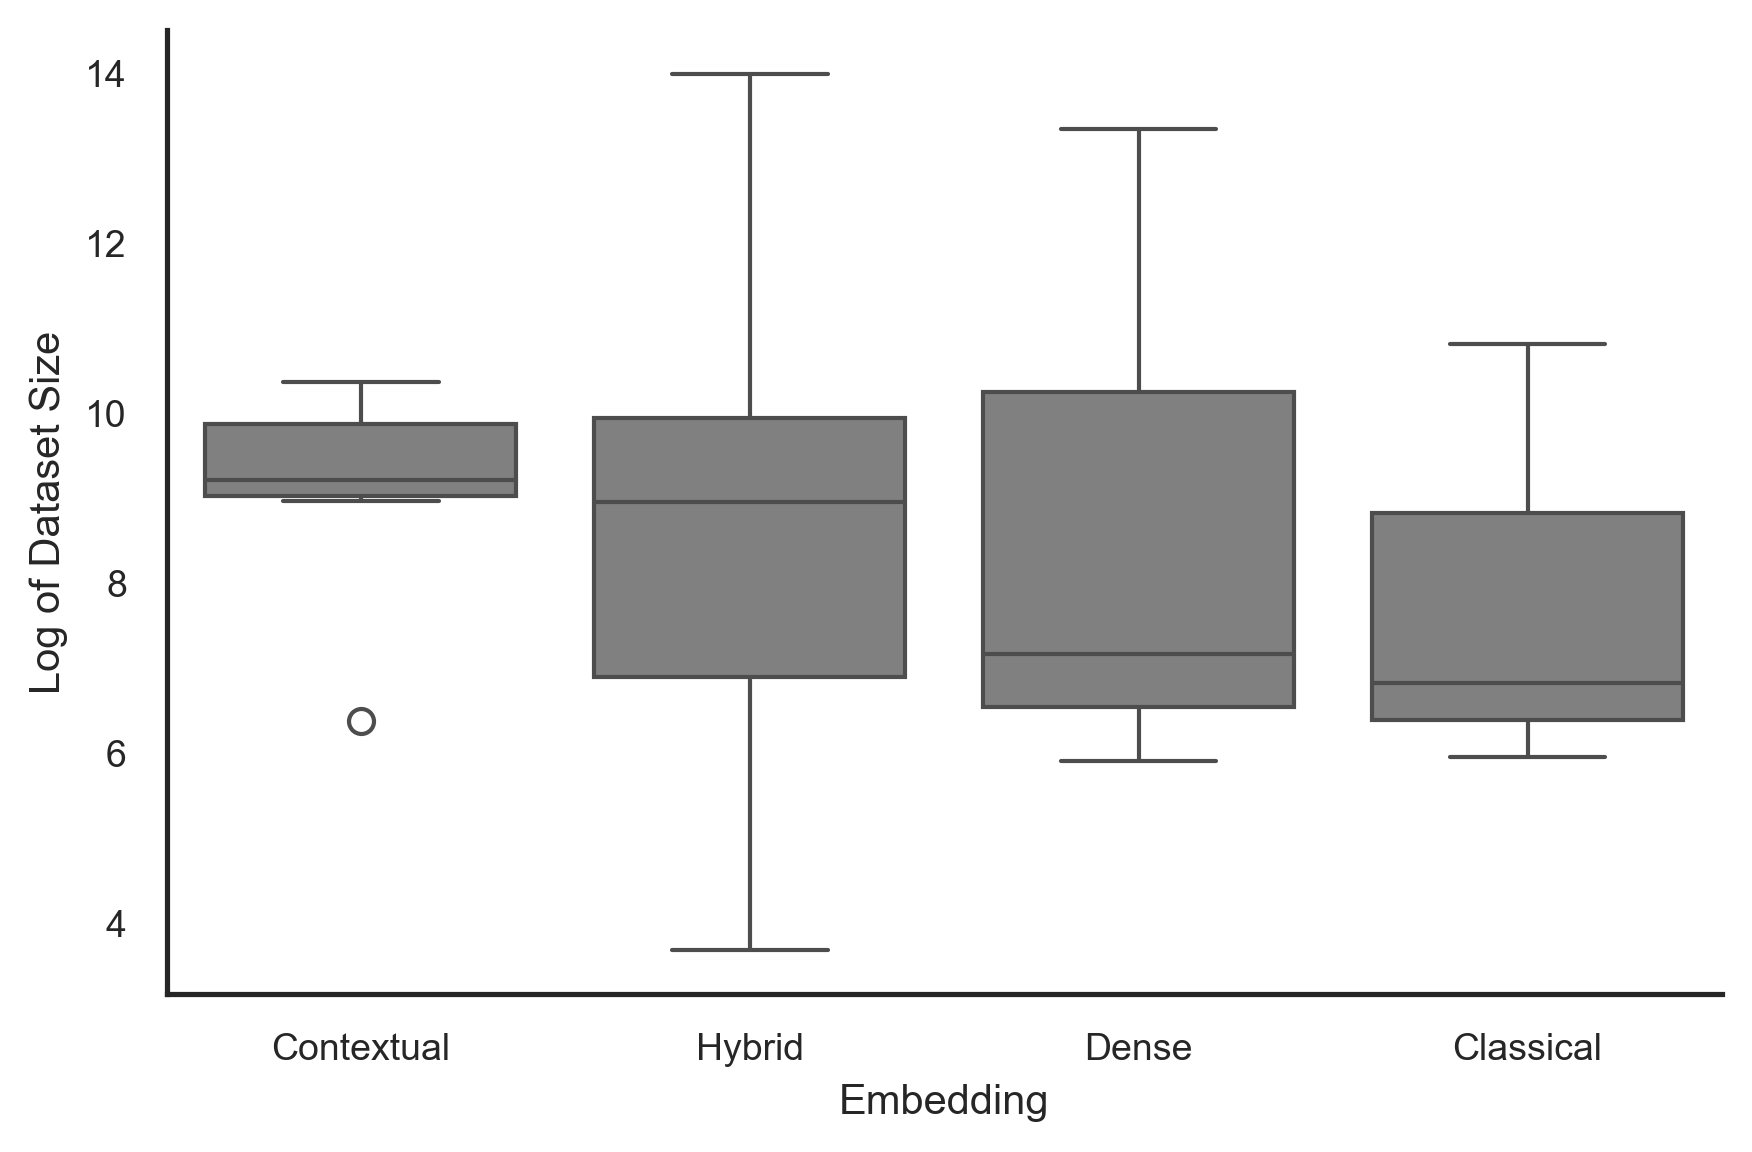

In [22]:
df_extraction_size = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_embedding, alias='embedding')
    .pipe(gerar_coluna_log_dataset_size, alias='Log Dataset Size')
    .select('Log Dataset Size', 'embedding', 'codigo_artigo')
    .group_by('codigo_artigo', 'embedding').mean()
    .to_pandas()
)

df_extraction_size_order = (
    df_extraction_size.groupby('embedding')['Log Dataset Size']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_extraction_size,
    x_col='embedding',
    y_col='Log Dataset Size',
    order=df_extraction_size_order,
    xlabel='Embedding',
    ylabel='Log of Dataset Size',
    img_filename='embedding_dataset_size_boxplot.pdf'
)


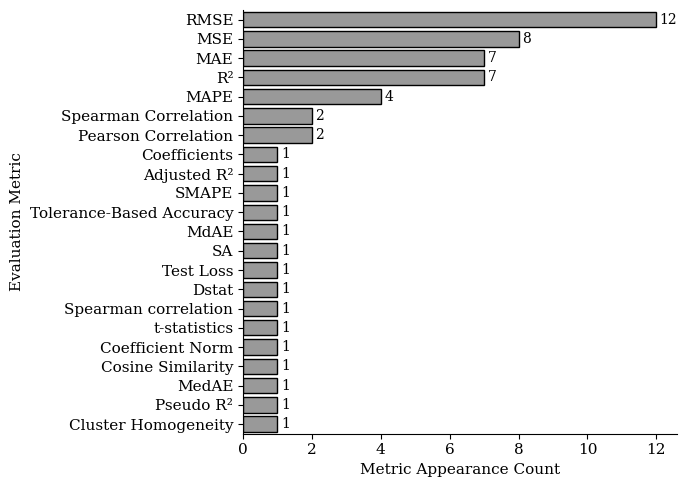

In [23]:

df_metric_types = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_metricas, alias='metricas')
    .select('codigo_artigo', 'metricas')
    .with_columns(
        pl.col('metricas').fill_null('RMSE')
    ).group_by(
        'metricas'
    ).n_unique().rename({'codigo_artigo': 'len'})
    .sort('len', descending=True).to_pandas().fillna(0)
)


plot_springer_style_bar_chart(
    df_metric_types,
    x_col='len',
    y_col='metricas',
    xlabel='Metric Appearance Count',
    ylabel='Evaluation Metric',
    img_filename='metric_proportions.pdf'
)

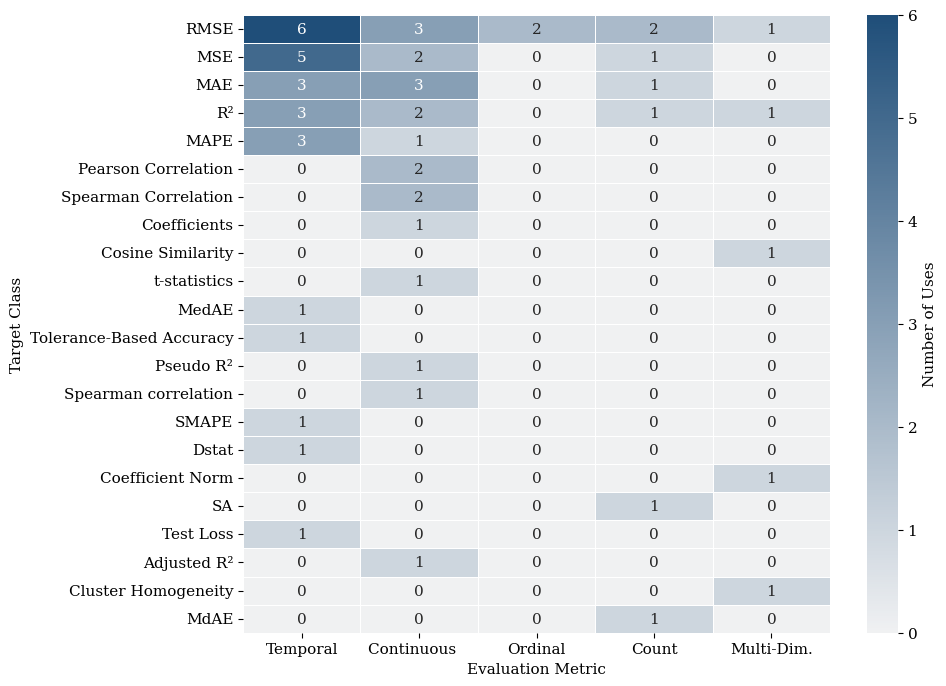

In [24]:

df_target_metric_types = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_alvo, alias='classe_alvo')
    .pipe(gerar_coluna_metricas, alias='metricas')
    .select('codigo_artigo', 'classe_alvo', 'metricas')
    .with_columns(
        pl.col('metricas').fill_null('RMSE')
    )
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='metricas', col_y='classe_alvo')
)

df_target_metric_types_order = (
    df_target_metric_types.sum(axis=1)
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_count_heat_map(
    df_target_metric_types.loc[df_target_metric_types_order],
    xlabel='Evaluation Metric',
    ylabel='Target Class',
    cbar_label='Number of Uses',
    img_filename='target_class_metric_heatmap.pdf'
)

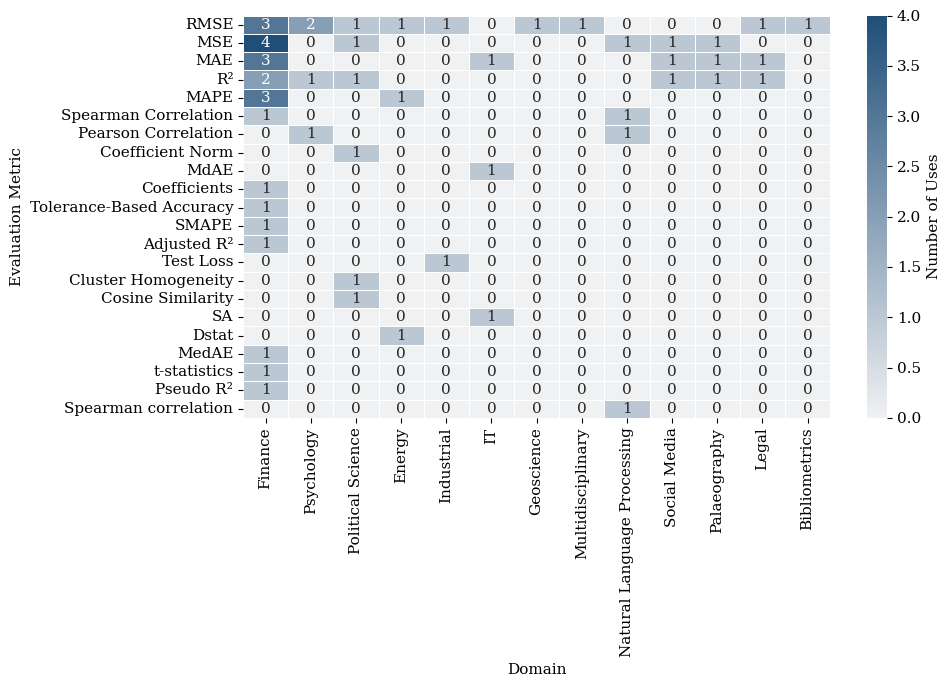

In [59]:

df_domain_metric_types = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_dominio, alias='Domain')
    .pipe(gerar_coluna_metricas, alias='Metric')
    .select('codigo_artigo', 'Domain', 'Metric')
    .with_columns(
        pl.col('Metric').fill_null('RMSE')
    )
    .pipe(gerar_df_heatmap_contagem, col_id='codigo_artigo', col_x='Metric', col_y='Domain')
)

df_domain_metric_types_order = (
    df_domain_metric_types.sum(axis=1)
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_count_heat_map(
    df_domain_metric_types.loc[df_domain_metric_types_order],
    xlabel='Domain',
    ylabel='Evaluation Metric',
    cbar_label='Number of Uses',
    img_filename='domain_metric_heatmap.pdf'
)

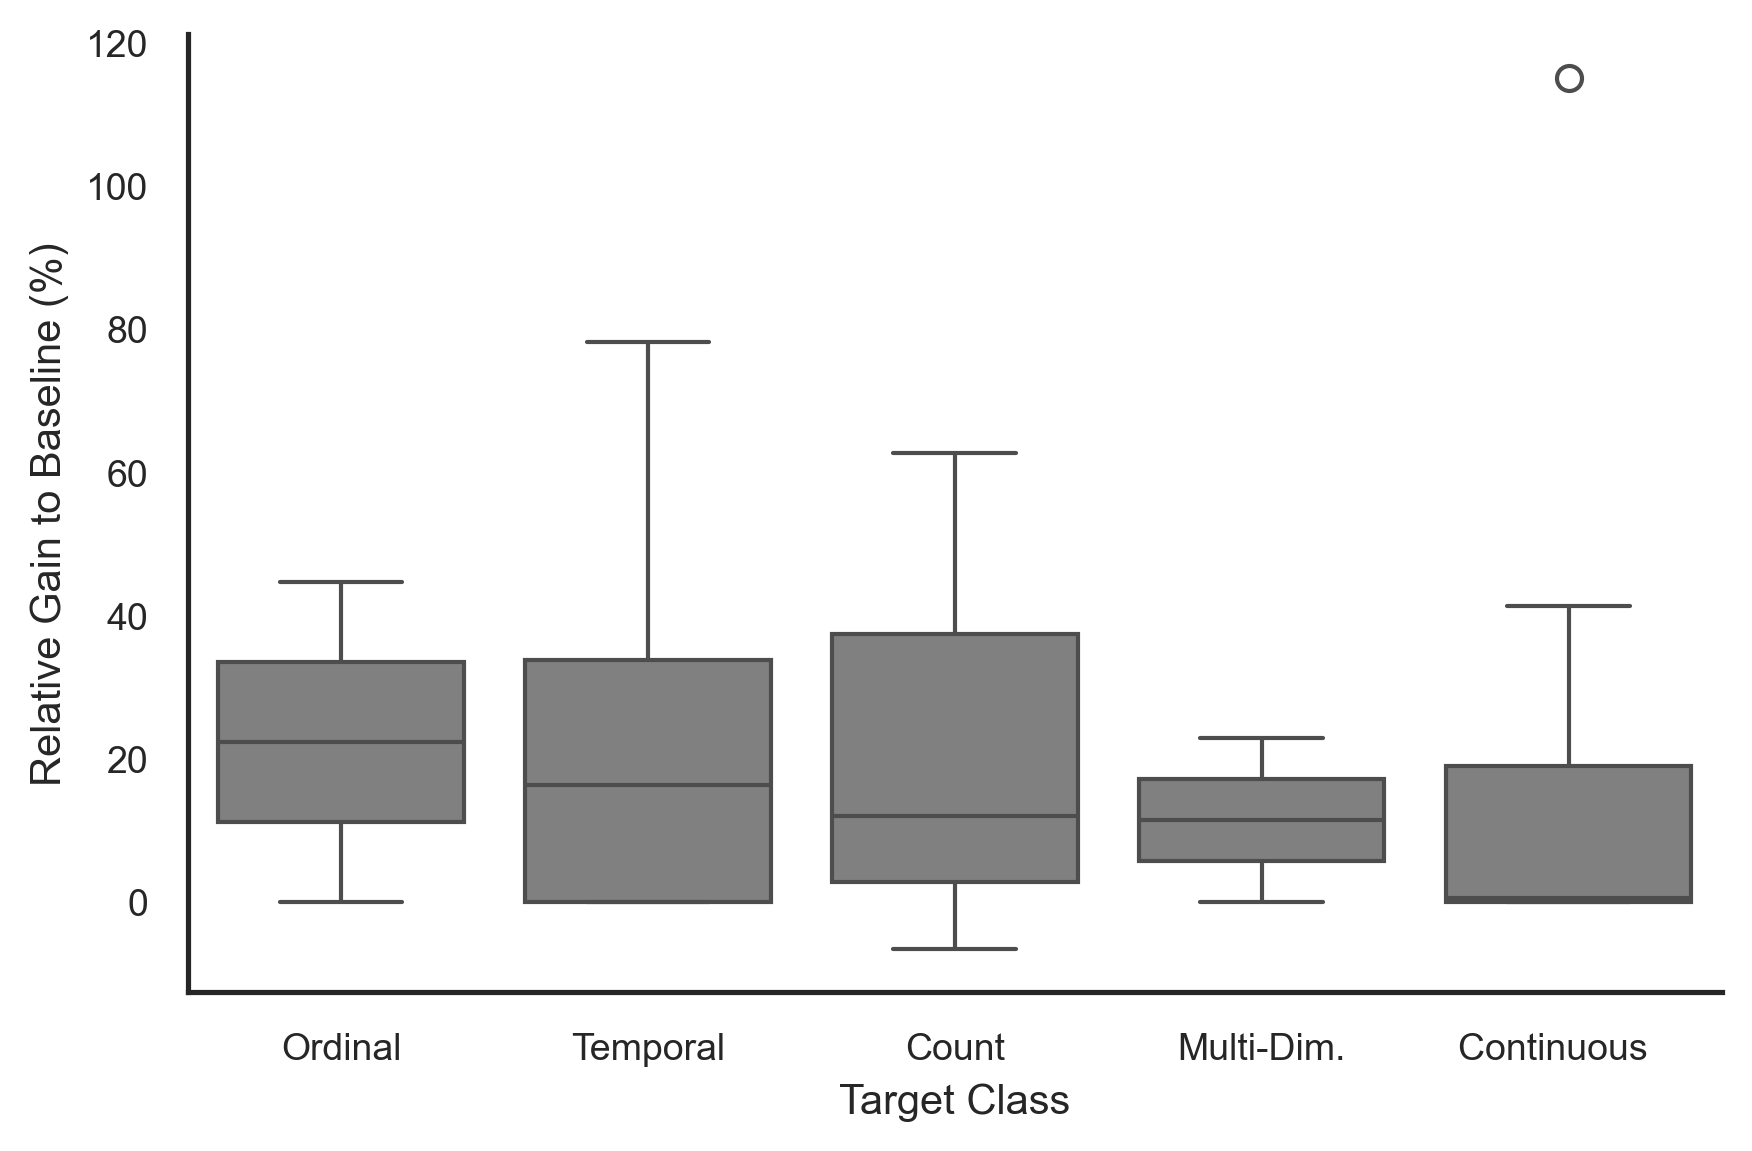

In [ ]:

df_target_gain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_alvo, alias='classe_alvo')
    .select('Ganho Relativo ao Baseline', 'classe_alvo', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_alvo').mean()
    .drop('codigo_artigo')
    .with_columns(
        (pl.col('Ganho Relativo ao Baseline') * 100).round(2).alias('Ganho Relativo ao Baseline'),
    )
    .to_pandas()
)

df_target_gain_order = (
    df_target_gain.groupby('classe_alvo')['Ganho Relativo ao Baseline']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_target_gain,
    x_col='classe_alvo',
    y_col='Ganho Relativo ao Baseline',
    order=df_target_gain_order,
    xlabel='Target Class',
    ylabel='Relative Gain to Baseline (%)',
    img_filename='target_class_relative_gain_boxplot.pdf'
)


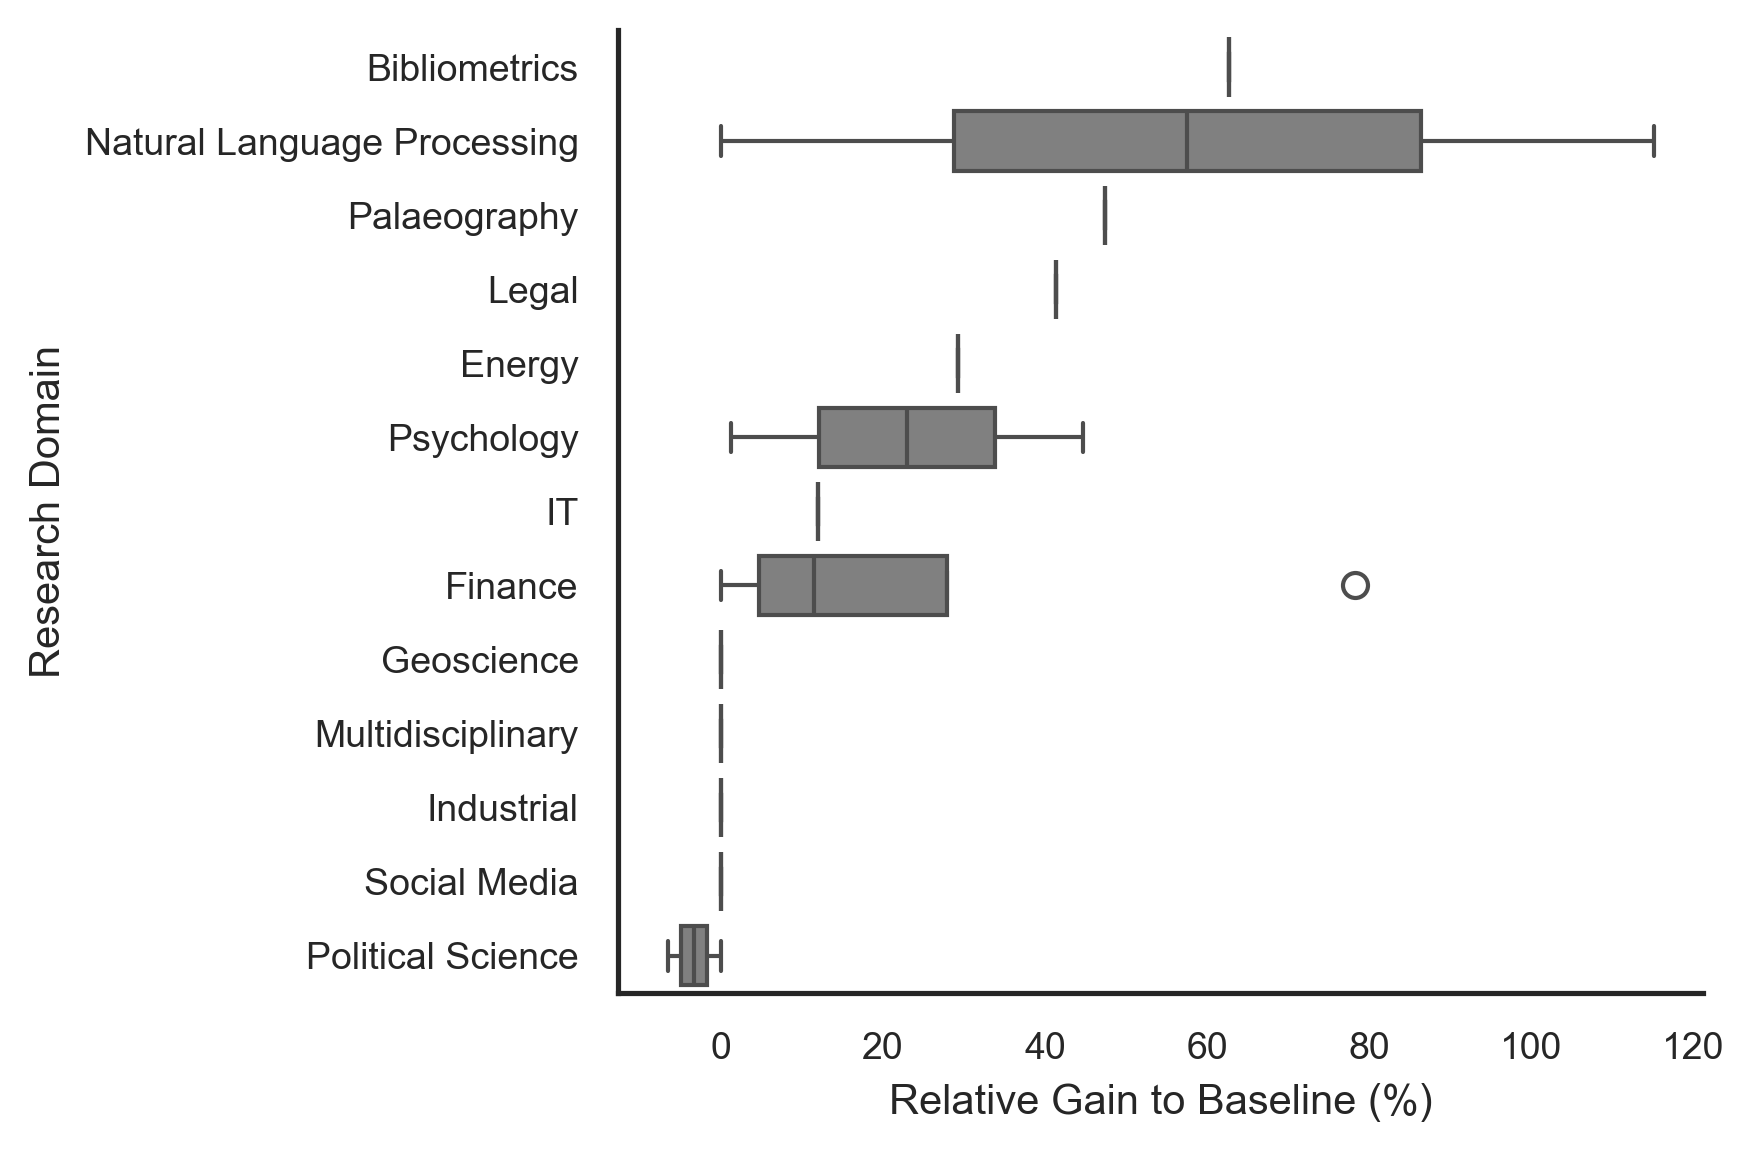

In [ ]:

df_domain_gain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_dominio, alias='dominio')
    .select('Ganho Relativo ao Baseline', 'dominio', 'codigo_artigo')
    .group_by('codigo_artigo', 'dominio').mean()
    .drop('codigo_artigo')
    #.group_by('dominio').mean()
    .with_columns(
        (pl.col('Ganho Relativo ao Baseline') * 100).round(2).alias('Ganho Relativo ao Baseline'),
    )
    .to_pandas()
)

df_domain_gain_order = (
    df_domain_gain.groupby('dominio')['Ganho Relativo ao Baseline']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_domain_gain,
    x_col='Ganho Relativo ao Baseline',
    y_col='dominio',
    order=df_domain_gain_order,
    xlabel='Relative Gain to Baseline (%)',
    ylabel='Research Domain',
    img_filename='domain_relative_gain_boxplot.pdf'
)


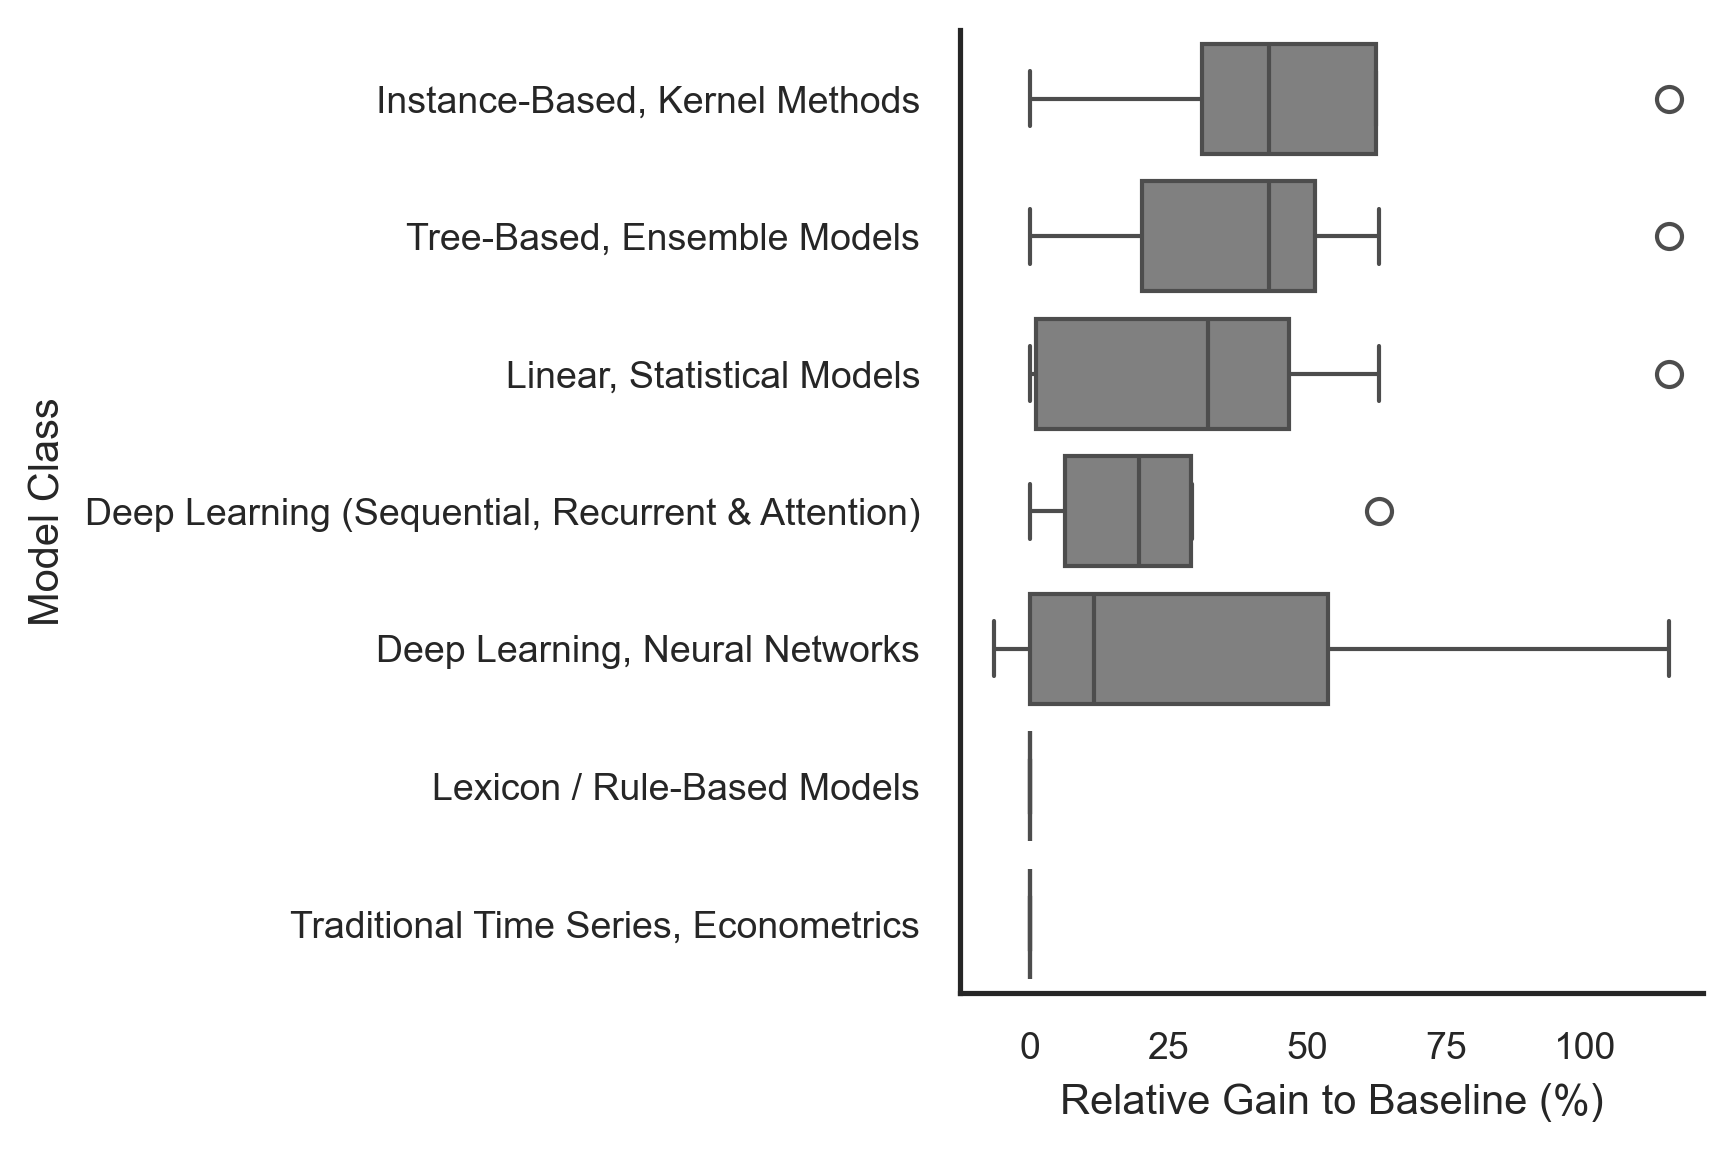

In [ ]:

df_model_gain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='classe_modelo')
    .select('Ganho Relativo ao Baseline', 'classe_modelo', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_modelo').mean()
    .drop('codigo_artigo')
    #.group_by('classe_modelo').mean()
    .with_columns(
        (pl.col('Ganho Relativo ao Baseline') * 100).round(2).alias('Ganho Relativo ao Baseline'),
    )
    .to_pandas()
)

df_model_gain_order = (
    df_model_gain.groupby('classe_modelo')['Ganho Relativo ao Baseline']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

plot_springer_style_boxplot(
    data=df_model_gain,
    x_col='Ganho Relativo ao Baseline',
    y_col='classe_modelo',
    order=df_model_gain_order,
    xlabel='Relative Gain to Baseline (%)',
    ylabel='Model Class',
    img_filename='model_relative_gain_boxplot.pdf'
)


C:\Users\MiguelZanchettin\AppData\Local\Temp\ipykernel_15384\1799660982.py:10: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


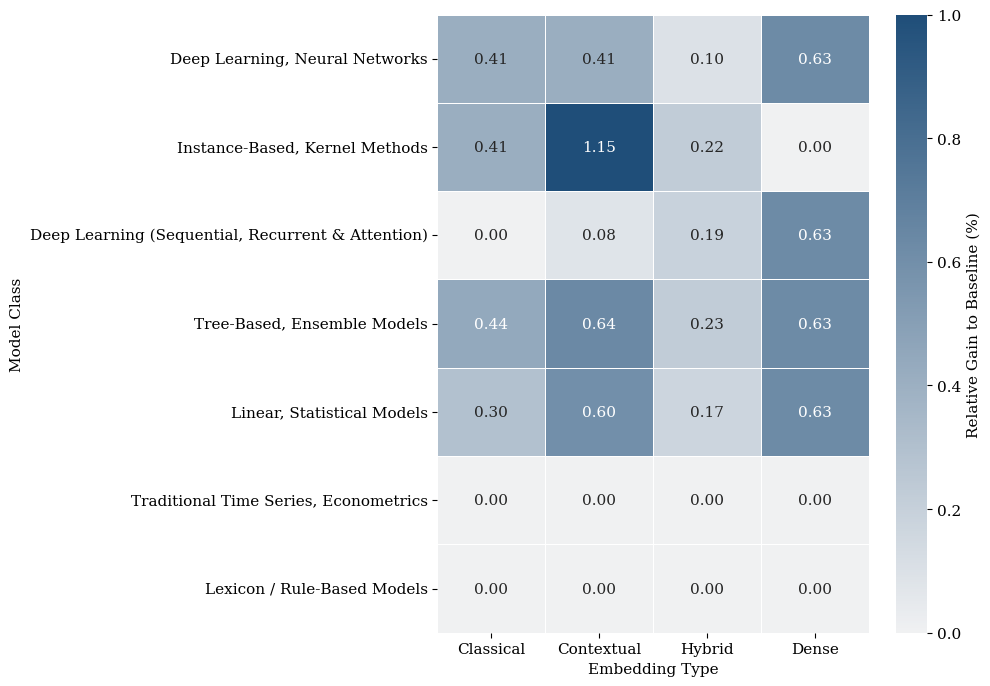

In [ ]:

df_model_embedding_gain = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='classe_modelo')
    .pipe(gerar_coluna_embedding, alias='embedding')
    .select('Ganho Relativo ao Baseline', 'classe_modelo', 'embedding', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_modelo', 'embedding').mean()
    .drop('codigo_artigo')
    .pivot(
        index='classe_modelo',
        columns='embedding',
        values='Ganho Relativo ao Baseline',
        aggregate_function='mean'
    ).to_pandas().set_index('classe_modelo').fillna(0)
)

plot_springer_style_count_heat_map(
    df_model_embedding_gain,
    xlabel='Embedding Type',
    ylabel='Model Class',
    cbar_label='Relative Gain to Baseline (%)',
    img_filename='model_embedding_relative_gain_heatmap.pdf',
    vmax=1.0,
    fmt='.2f'
)


<>:27: SyntaxWarning:

invalid escape sequence '\d'

<>:27: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\MiguelZanchettin\AppData\Local\Temp\ipykernel_15384\2935109532.py:27: SyntaxWarning:

invalid escape sequence '\d'



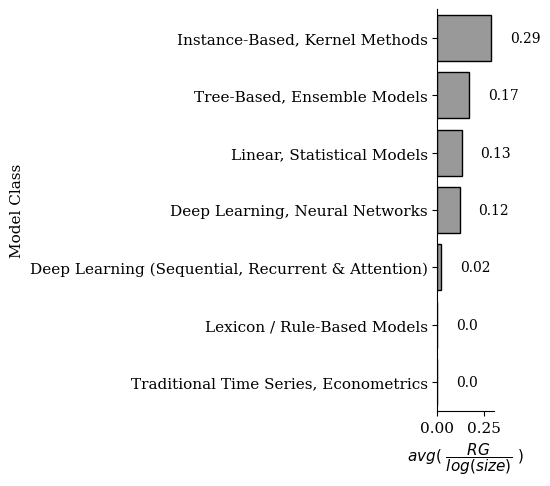

In [68]:

df_model_gain_size = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='classe_modelo')
    .pipe(gerar_coluna_log_dataset_size, alias='Log Dataset Size')
    .select('Ganho Relativo ao Baseline', 'classe_modelo', 'Log Dataset Size', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_modelo').mean()
    .drop('codigo_artigo')
    .with_columns(
        (pl.col('Ganho Relativo ao Baseline') / pl.col('Log Dataset Size').exp()).alias('relative_efficiency'),
    ).select(
        'classe_modelo', 'relative_efficiency'
    ).group_by(
        'classe_modelo'
    ).mean().sort('relative_efficiency', descending=True)
    .with_columns(
        (pl.col('relative_efficiency') * 100).round(2)
    )
    .to_pandas().set_index('classe_modelo').fillna(0)
)

plot_springer_style_bar_chart(
    df_model_gain_size,
    x_col='relative_efficiency',
    y_col='classe_modelo',
    xlabel='$avg( \\ \dfrac{RG}{log(size)} \\ )$',
    ylabel='Model Class',
    img_filename='model_relative_gain_per_size_barplot.pdf'
)


<>:26: SyntaxWarning:

invalid escape sequence '\d'

<>:26: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\MiguelZanchettin\AppData\Local\Temp\ipykernel_15384\1684062038.py:26: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\MiguelZanchettin\AppData\Local\Temp\ipykernel_15384\1684062038.py:14: DeprecationWarning:

the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.



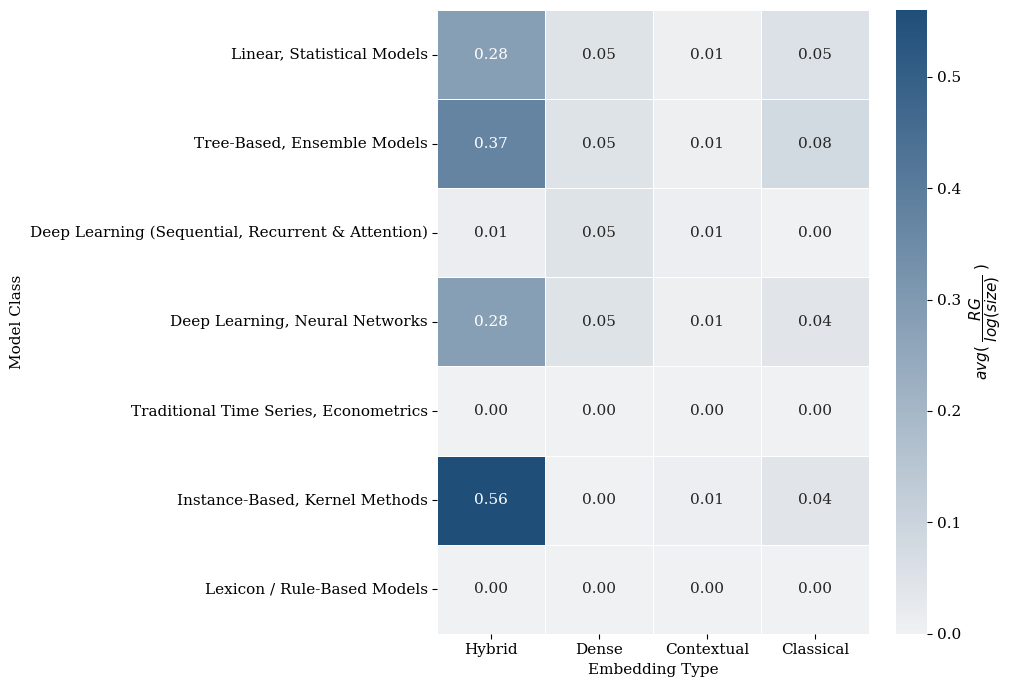

In [69]:

df_model_embedding_gain_size = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_classe_modelo, alias='classe_modelo')
    .pipe(gerar_coluna_embedding, alias='embedding')
    .pipe(gerar_coluna_log_dataset_size, alias='Log Dataset Size')
    .select('Ganho Relativo ao Baseline', 'classe_modelo', 'embedding', 'Log Dataset Size', 'codigo_artigo')
    .group_by('codigo_artigo', 'classe_modelo', 'embedding').mean()
    .drop('codigo_artigo')
    .with_columns(
        (pl.col('Ganho Relativo ao Baseline') / pl.col('Log Dataset Size').exp() * 100).round(2).alias('relative_efficiency'),
    )
    .pivot(
        index='classe_modelo',
        columns='embedding',
        values='relative_efficiency',
        aggregate_function='mean'
    ).to_pandas().set_index('classe_modelo').fillna(0)
)

plot_springer_style_count_heat_map(
    df_model_embedding_gain_size,
    xlabel='Embedding Type',
    ylabel='Model Class',
    cbar_label='$avg( \\ \dfrac{RG}{log(size)} \\ )$',
    img_filename='model_embedding_relative_efficiency_heatmap.pdf',
    #vmax=1.0,
    fmt='.2f'
)


In [31]:
def gerar_coluna_limitacoes(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Limitações')
                .str.strip_chars()
                .str.split(',')
        ).explode(
            'Limitações'
        ).with_columns(
            pl.col('Limitações')
                .str.strip_chars()
                .alias(alias)
        )
    )

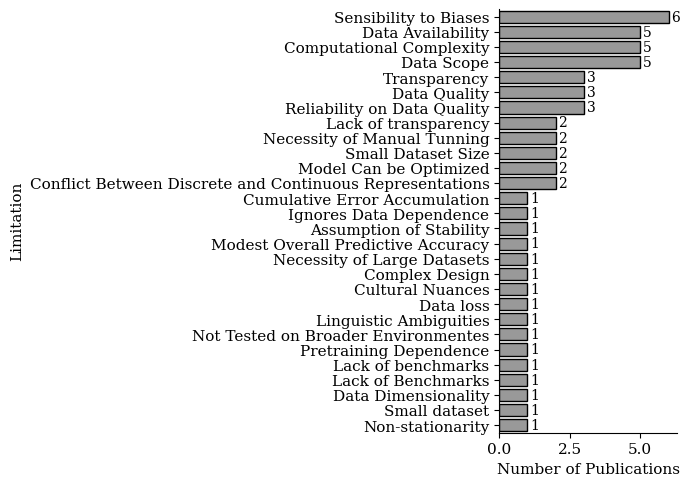

In [32]:

df_limitation_count = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_limitacoes, alias='Limitacao')
    .select('Limitacao', 'codigo_artigo')
    .group_by('Limitacao')
    .n_unique().rename({'codigo_artigo': 'len'})
    .sort('len', descending=True)
    .to_pandas()
)

plot_springer_style_bar_chart(
    df_limitation_count,
    x_col='len',
    y_col='Limitacao',
    xlabel='Number of Publications',
    ylabel='Limitation',
    img_filename='limitation_count_barplot.pdf'
)


In [33]:
def gerar_coluna_vantagens(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Vantagens')
                .str.strip_chars()
                .str.split(',')
        ).explode(
            'Vantagens'
        ).with_columns(
            pl.col('Vantagens')
                .str.strip_chars()
                .str.to_titlecase()
                .alias(alias)
        )
    )

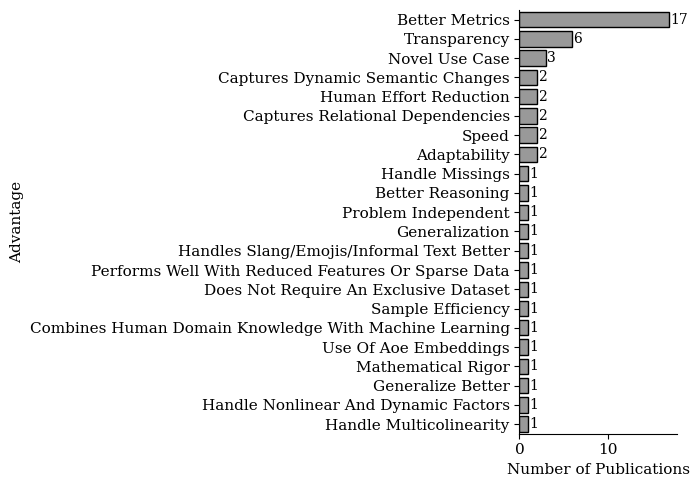

In [34]:

df_advantages_count = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_vantagens, alias='Vantagem')
    .select('Vantagem', 'codigo_artigo')
    .group_by('Vantagem')
    .n_unique().rename({'codigo_artigo': 'len'})
    .sort('len', descending=True)
    .to_pandas()
)

plot_springer_style_bar_chart(
    df_advantages_count,
    x_col='len',
    y_col='Vantagem',
    xlabel='Number of Publications',
    ylabel='Advantage',
    img_filename='advantage_count_barplot.pdf'
)


In [35]:
def gerar_coluna_contribuicoes(df: pl.DataFrame, alias: str) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col('Contribuições')
                .str.strip_chars()
                .str.split(',')
        ).explode(
            'Contribuições'
        ).with_columns(
            pl.col('Contribuições')
                .str.strip_chars()
                .alias(alias)
        )
    )

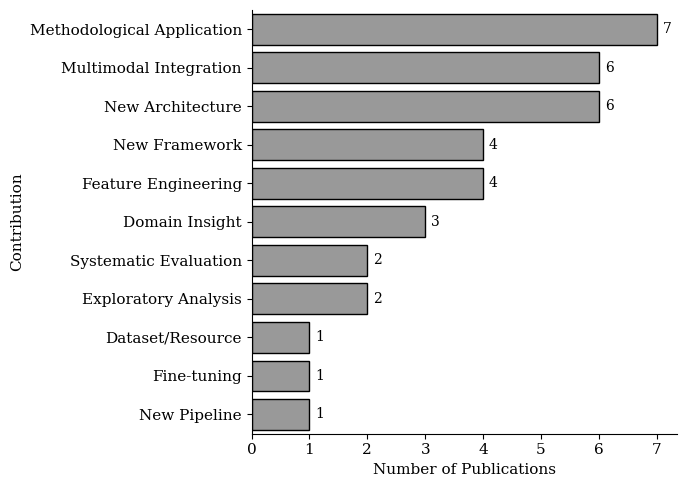

In [36]:

df_contributions_count = (
    df_data
    .pipe(filtrar_apenas_artigos_com_dados)
    .pipe(renomear_codigo_artigo, alias='codigo_artigo')
    .pipe(gerar_coluna_contribuicoes, alias='Contribuição')
    .select('Contribuição', 'codigo_artigo')
    .group_by('Contribuição')
    .n_unique().rename({'codigo_artigo': 'len'})
    .sort('len', descending=True)
    .to_pandas()
)

plot_springer_style_bar_chart(
    df_contributions_count,
    x_col='len',
    y_col='Contribuição',
    xlabel='Number of Publications',
    ylabel='Contribution',
    img_filename='contribution_count_barplot.pdf'
)


In [37]:
#! pip install plotly
! pip install --upgrade kaleido



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import plotly.graph_objects as go

# Lista de rótulos com ajuste manual de espaços para os últimos nós
label = [
    "GS (410)", "IC I (170)", "IC II (119)", "IC III (110)", "IC IV (38)",
    "EC I (38)", "EC II (38)", "EC III (38)", "EC IV (35)", "EC V (23)",
    "AC (21)", # Nó 10

    "IJDSA (225)", "IC I (172)", "IC II (172)", "IC III (132)", "IC IV (12)",
    "EC I (11)", "EC II (11)", "EC III (11)", "EC IV (6)", "EC V (3)",
    "AC (3)",  # Nó 21

    # O truque: Muitos espaços antes para empurrar o texto para a DIREITA do nó
    "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<b>24</b>"
]

fig = go.Figure(data=[go.Sankey(
    # 'snap' evita que os nós fiquem flutuando em alturas estranhas
    arrangement = "snap",
    node = dict(
      pad = 18, # Aumentei o pad para separar as linhas verticalmente
      thickness = 10,
      line = dict(color = "white", width = 1),
      label = label,
      color = "#2c3e50",
      # Força o texto a ficar fora do nó sempre que possível
      hoverinfo = 'all'
    ),
    link = dict(
      source = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
      target = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 22, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22],
      value = [410, 170, 119, 110, 38, 38, 38, 38, 35, 23, 21, 225, 172, 172, 132, 12, 11, 11, 11, 6, 3, 3],
      color = ["rgba(44, 62, 80, 0.4)"] * 11 + ["rgba(127, 140, 141, 0.4)"] * 11
    )
)])

fig.update_layout(
    font=dict(size=12, family="Arial", color="black"), # Diminuir o tamanho ajuda muito
    margin=dict(l=50, r=150, t=50, b=50), # Margem direita grande para o texto não sumir
    paper_bgcolor='white',
    width=1200, # Aumentar a largura total dá mais "fôlego" para os nomes
    height=500
)

# Exportação para SVG
#fig.write_image("fluxo_sankey.svg", width=1200, height=600, scale=1)
fig.write_image(
    "sankey_plot.pdf",
    format="pdf",
    width=1200,
    height=600,
    scale=2  # higher scale = better resolution
)

#fig.show()